<a href="https://colab.research.google.com/github/TatkovDmitriy/-/blob/main/%D0%A2%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_HR_BP_%D0%A2_%D0%91%D0%B0%D0%BD%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -U -q PyDrive
# 📦 Загрузка библиотек для анализа данных

# Работа с таблицами и массивами
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
# Настройки визуализации
plt.style.use('ggplot')  # безопасная альтернатива, встроенная в matplotlib
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_palette('Set2')

# Статистика и A/B-тесты
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Работа с датами
import datetime as dt
from google.colab import auth
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from oauth2client.client import GoogleCredentials


# Отображение и подавление предупреждений
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
print("библиотеки загружены")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 25.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
библиотеки загружены


In [4]:

# Исходная view-ссылка
shared_url = 'https://drive.google.com/file/d/1Izx_RzL59oMlmAYafA_4oa7OI8lfoEuG/view?usp=drive_link'

# Извлекаем file_id и строим прямую ссылку
file_id = shared_url.split('/d/')[1].split('/')[0]
csv_url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Читаем CSV
df = pd.read_csv(csv_url, sep=';', encoding='utf-8', on_bad_lines='skip')

print(f"✅ Датасет загружен: {df.shape}")

# Выводим preview
display("Первые строки данных:")
display(df.head(5))

display("Информация о данных:")
display(df.info())

✅ Датасет загружен: (821, 20)


'Первые строки данных:'

,ФИО,experience_group,experience_group_detail,seniority_RLS,Оценка_ревью_RLS,Должность,Тип трудоустройства,УС - Уровень 3,УС - Уровень 4,УС - Уровень 5,ФИО HRBP,ФИО руководителя,Стрим,Специализация,Покраска,IT/non-IT по покраске,Digital/ non-Digital,Инициатор увольнения_RLS,Группа причин увольнений_RLS,Причина увольнения_RLS
0,LoilLi3jFr,Стаж от 5 лет и более,5 лет и более,Junior,Не участвовал в ревью,Старший специалист 3 категории,Штатный сотрудник,Операционный юнит,Департамент клиентского обслуживания,Поддержка клиентов инвестиций и мобайла,sFSToUzepx,kSrOtaJHya,Поддержка клиентов физ.лиц,Бэк-офис физ лица,Line,NonIT,non-Digital,Инициатива сотрудника,Личное,Меняю профессию/ухожу в свой проект/рассматрив...
1,R6Ue0RgXsj,Стаж от 5 лет и более,5 лет и более,Junior,Хорошо,Ведущий специалист,Штатный сотрудник,Операционный юнит,Аналитика обслуживания,Управление аналитики и прогнозирования,S8PWER5ceo,1HSkqEHyoU,Операционная эффективность,Планирование,Support,NonIT,non-Digital,Инициатива сотрудника,Работа,Психологически тяжело работать/сложно работать...
2,Rd5CaEFozZ,Стаж от 2 до 5 лет,4 - 5 лет,Junior,Не участвовал в ревью,Старший специалист 3 категории,Штатный сотрудник,Операционный юнит,Департамент клиентского обслуживания,Поддержка клиентов инвестиций и мобайла,sFSToUzepx,kSrOtaJHya,Поддержка клиентов физ.лиц,Бэк-офис физ лица,Line,NonIT,non-Digital,Инициатива сотрудника,Работа,Психологически тяжело работать/сложно работать...
3,F23rXpBpX6,Стаж от 2 до 5 лет,3 - 4 года,Junior,Не участвовал в ревью,Старший специалист,Штатный сотрудник,Операционный юнит,Департамент клиентского обслуживания,Поддержка клиентов инвестиций и мобайла,Olbtwbep9M,r14vzofIMi,Поддержка клиентов физ.лиц,Мобайл обслуживание,Line,NonIT,non-Digital,Инициатива сотрудника,Личное,По состоянию здоровья (своего или близкого чел...
4,bw7RvsokrO,Стаж от 2 до 5 лет,3 - 4 года,Junior,Не участвовал в ревью,Старший специалист,Штатный сотрудник,Операционный юнит,Департамент клиентского обслуживания,Поддержка клиентов инвестиций и мобайла,Olbtwbep9M,rlPDVUnQW0,Поддержка клиентов физ.лиц,Мобайл обслуживание,Line,NonIT,non-Digital,Инициатива сотрудника,Работа,Психологически тяжело работать/сложно работать...


'Информация о данных:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821 entries, 0 to 820
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   ФИО                           821 non-null    object
 1   experience_group              821 non-null    object
 2   experience_group_detail       821 non-null    object
 3   seniority_RLS                 808 non-null    object
 4   Оценка_ревью_RLS              821 non-null    object
 5   Должность                     821 non-null    object
 6   Тип трудоустройства           821 non-null    object
 7   УС - Уровень 3                821 non-null    object
 8   УС - Уровень 4                821 non-null    object
 9   УС - Уровень 5                821 non-null    object
 10  ФИО HRBP                      821 non-null    object
 11  ФИО руководителя              821 non-null    object
 12  Стрим                         819 non-null    object
 13  Специализация       

None

In [5]:
# === Подготовка и очистка: работаем с копией, исходный df не трогаем ===
df_clean = df.copy(deep=True)

# 1) Базовая очистка текстов: trim + схлопывание множественных пробелов
import re

obj_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

def _clean_str(x):
    if isinstance(x, str):
        x = x.strip()
        x = re.sub(r"\s+", " ", x)
    return x

for col in obj_cols:
    df_clean[col] = df_clean[col].map(_clean_str)

# 2) Отчёт о пропусках
missing_report = (
    df_clean.isna().sum().to_frame("missing")
    .assign(missing_pct=lambda t: (t["missing"] / len(df_clean) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)
print("🧹 Пропуски по столбцам (top 20):")
print(missing_report.head(20))

# 3) Унификация категорий стажа
exp_group_order = [
    "Без опыта",
    "Стаж до 1 года",
    "Стаж от 1 до 2 лет",
    "Стаж от 2 до 5 лет",
    "Стаж от 5 лет и более",
]

exp_detail_order = [
    "менее 6 мес",
    "6 - 12 мес",
    "1 - 2 года",
    "2 - 3 года",
    "3 - 4 года",
    "4 - 5 лет",
    "5 лет и более",
]

def to_ordered_category(frame, col, order_list):
    if col not in frame.columns:
        return
    # Нормализация возможных синонимов
    if col == "experience_group":
        repl = {
            "Стаж до года": "Стаж до 1 года",
            "Стаж 1-2 года": "Стаж от 1 до 2 лет",
            "Стаж 2-5 лет": "Стаж от 2 до 5 лет",
            "Стаж 5+ лет": "Стаж от 5 лет и более",
        }
        frame[col] = frame[col].replace(repl)

    if col == "experience_group_detail":
        repl = {
            "до 6 мес": "менее 6 мес",
            "0-6 мес": "менее 6 мес",
            "6-12 мес": "6 - 12 мес",
            "1-2 года": "1 - 2 года",
            "2-3 года": "2 - 3 года",
            "3-4 года": "3 - 4 года",
            "4-5 лет": "4 - 5 лет",
            "5+ лет": "5 лет и более",
        }
        frame[col] = frame[col].replace(repl)

    # Перевод в ordered category по заданному порядку
    frame[col] = frame[col].astype("category")
    frame[col] = frame[col].cat.set_categories(order_list, ordered=True)

to_ordered_category(df_clean, "experience_group", exp_group_order)
to_ordered_category(df_clean, "experience_group_detail", exp_detail_order)

# 4) Унификация грейдов (seniority)
seniority_order = ["Intern", "Junior", "Middle", "Senior", "Lead", "Principal", "Head"]
if "seniority_RLS" in df_clean.columns:
    df_clean["seniority_RLS"] = df_clean["seniority_RLS"].astype("category")
    df_clean["seniority_RLS"] = df_clean["seniority_RLS"].cat.set_categories(seniority_order, ordered=True)

# 5) Мягкая нормализация бинарных справочников Digital / IT
def normalize_binary_label(x, true_labels=("digital",),
                           false_labels=("non-digital","non digital","non_digital","non digital ")):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return x
    s = str(x).strip().lower().replace("_", " ").replace("-", " ")
    if s in true_labels:
        return "Digital"
    if s in false_labels:
        return "non-Digital"
    return x

for col in ["Digital/ non-Digital", "IT/non-IT по покраске"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(normalize_binary_label)

# 6) Перевод прочих object-колонок в category (для оптимизации группировок)
for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] = df_clean[col].astype("category")

# 7) Контроль: уникальные значения по ключевым полям
key_cols = [
    "experience_group", "experience_group_detail",
    "seniority_RLS", "Оценка_ревью_RLS", "Тип трудоустройства",
    "Стрим", "Специализация", "Покраска",
    "IT/non-IT по покраске", "Digital/ non-Digital",
    "Инициатор увольнения_RLS", "Группа причин увольнений_RLS"
]
print("\n🔎 Уникальные значения (до 15 на колонку):")
for col in key_cols:
    if col in df_clean.columns:
        vals = df_clean[col].dropna().unique().tolist()
        print(f" - {col}: {vals[:15]}{' ...' if len(vals) > 15 else ''}")

# 8) Итоги по типам и размеру
print(f"\n✅ Очистка завершена. Размер df_clean: {df_clean.shape}")
print("Типы данных (первые 12 столбцов):")
print(df_clean.dtypes.head(12))


🧹 Пропуски по столбцам (top 20):
                              missing  missing_pct
seniority_RLS                      13         1.58
Специализация                       2         0.24
Покраска                            2         0.24
IT/non-IT по покраске               2         0.24
Стрим                               2         0.24
experience_group_detail             0         0.00
ФИО                                 0         0.00
experience_group                    0         0.00
Оценка_ревью_RLS                    0         0.00
Должность                           0         0.00
Тип трудоустройства                 0         0.00
УС - Уровень 3                      0         0.00
ФИО руководителя                    0         0.00
ФИО HRBP                            0         0.00
УС - Уровень 5                      0         0.00
УС - Уровень 4                      0         0.00
Digital/ non-Digital                0         0.00
Инициатор увольнения_RLS            0         0.0

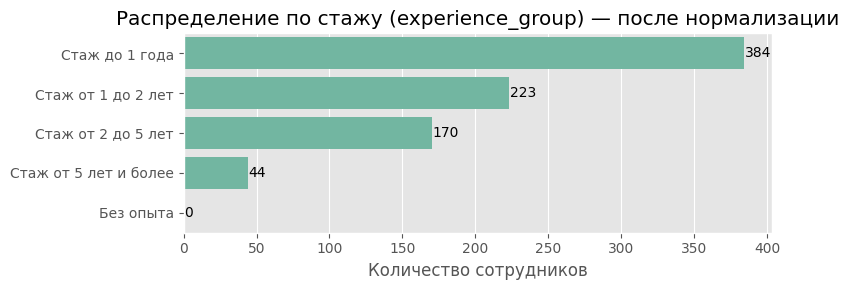

,count,pct
experience_group,,
Стаж до 1 года,384,46.77
Стаж от 1 до 2 лет,223,27.16
Стаж от 2 до 5 лет,170,20.71
Стаж от 5 лет и более,44,5.36
Без опыта,0,0.00


In [6]:
# === График 1: Распределение по experience_group с нормализацией (сортировка по убыванию, подписи) ===

# Нормализация experience_group
def _norm_exp_group(s):
    if pd.isna(s):
        return pd.NA
    t = str(s).strip().lower().replace("–", "-").replace("—", "-")
    t = " ".join(t.split())
    if "без опыта" in t:
        return "Без опыта"
    if "до 1" in t or "до года" in t or "менее" in t or "3 до 6" in t or "полугода" in t:
        return "Стаж до 1 года"
    if "1-2" in t or "1 - 2" in t or "от 1 до 2" in t:
        return "Стаж от 1 до 2 лет"
    if "2-5" in t or "2 - 5" in t or "от 2 до 5" in t or "2 до 5" in t or "2-3" in t or "3 - 4" in t or "4 - 5" in t:
        return "Стаж от 2 до 5 лет"
    if "5" in t:  # включает '5 лет и более', '5+ лет'
        return "Стаж от 5 лет и более"
    return pd.NA

df_clean['experience_group'] = df['experience_group'].map(_norm_exp_group)

# Восстановление из experience_group_detail, если возможно
detail_to_group = {
    "менее 6 мес": "Стаж до 1 года",
    "6 - 12 мес": "Стаж до 1 года",
    "1 - 2 года": "Стаж от 1 до 2 лет",
    "2 - 3 года": "Стаж от 2 до 5 лет",
    "3 - 4 года": "Стаж от 2 до 5 лет",
    "4 - 5 лет": "Стаж от 2 до 5 лет",
    "5 лет и более": "Стаж от 5 лет и более",
}
mask_na = df_clean['experience_group'].isna()
if 'experience_group_detail' in df.columns:
    df_clean.loc[mask_na, 'experience_group'] = (
        df.loc[mask_na, 'experience_group_detail']
        .map(lambda x: detail_to_group.get(x, pd.NA))
    )

# Порядок категорий
order = [
    "Без опыта",
    "Стаж до 1 года",
    "Стаж от 1 до 2 лет",
    "Стаж от 2 до 5 лет",
    "Стаж от 5 лет и более",
]
df_clean['experience_group'] = pd.Categorical(df_clean['experience_group'], categories=order, ordered=True)

# Подсчёт и сортировка
counts = df_clean['experience_group'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# График
plot_df = dist_tbl.reset_index().rename(columns={'index': 'experience_group'})
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='experience_group',
    x='count',
    orient='h',
    order=plot_df['experience_group']
)
plt.title('Распределение по стажу (experience_group) — после нормализации')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height()/2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


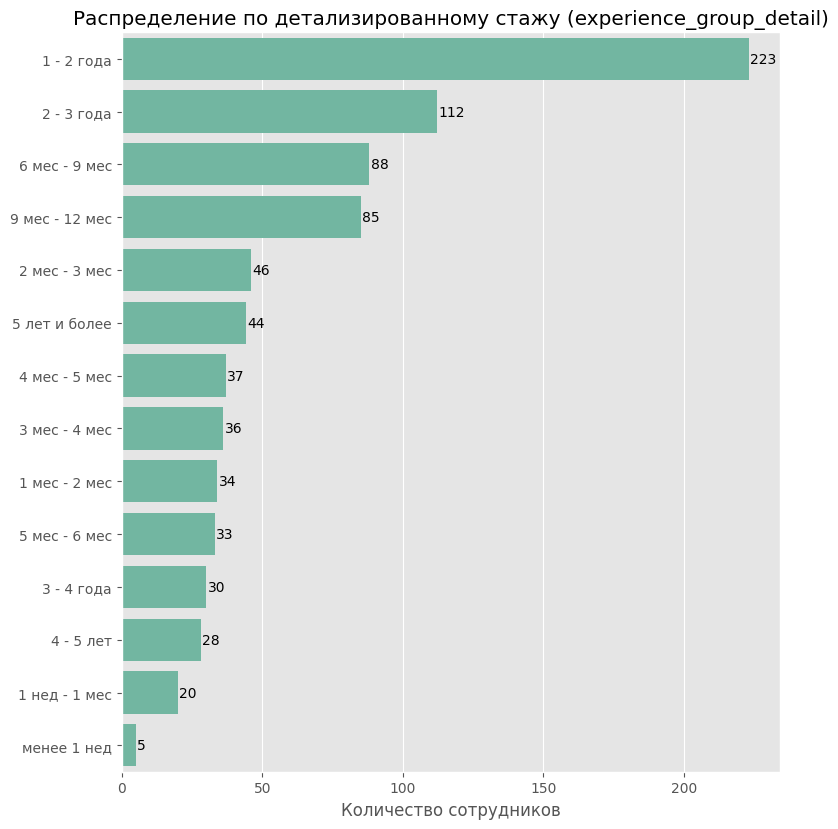

,count,pct
experience_group_detail,,
1 - 2 года,223,27.16
2 - 3 года,112,13.64
6 мес - 9 мес,88,10.72
9 мес - 12 мес,85,10.35
2 мес - 3 мес,46,5.60
5 лет и более,44,5.36
4 мес - 5 мес,37,4.51
3 мес - 4 мес,36,4.38
1 мес - 2 мес,34,4.14


In [26]:
# === График 2: Распределение по experience_group_detail с нормализацией ===

# Нормализация категорий
mapping = {
    'Стаж менее 3 месяцев': 'менее 6 мес',
    'Стаж от 3 до 6 мес': 'менее 6 мес',
    'Стаж от полугода до 1 года': '6 - 12 мес'
}

df_clean['experience_group_detail'] = df['experience_group_detail'].replace(mapping)

# Подсчёт и сортировка
counts = df_clean['experience_group_detail'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных для графика
plot_df = dist_tbl.reset_index().rename(columns={'index': 'experience_group_detail'})

# Визуализация
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='experience_group_detail',
    x='count',
    orient='h',
    order=plot_df['experience_group_detail']
)
plt.title('Распределение по детализированному стажу (experience_group_detail)')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)

## СЕГМЕНТ «Стаж» — глубокий разбор и действия

### Что видим (факты)
- **Стаж до 1 года — 46.77% (384)** → почти половина состава — «новички».
- **1–2 года — 27.16% (223)** и **2–5 лет — 20.71% (170)** → ядро — ранняя и средняя стадия.
- **5+ лет — 5.36% (44)** → тонкий слой носителей институциональных знаний.

**Детализация 0–12 мес:**
- **6–9 мес — 10.72% (88)** и **9–12 мес — 10.35% (85)** — два пика внутри первого года (критические окна оттока после адаптации).
- Очень ранние когорты присутствуют, но малы: **1–2 мес — 4.14%**, **2–3 мес — 5.60%**, **3–4 мес — 4.38%**, **4–5 мес — 4.51%**, **5–6 мес — 4.02%**, **1 нед–1 мес — 2.44%**, **<1 нед — 0.61%**.
- За пределами года ядро — **1–2 года — 27.16%**, далее **2–3 года — 13.64%**, **3–4 года — 3.65%**, **4–5 лет — 3.41%**, **5+ — 5.36%**.

### Интерпретация (риски и гипотезы)
1) **Ранний отток после «медового месяца».** Пики 6–12 мес указывают на выгорание/несовпадение ожиданий после базовой адаптации.  
2) **Недостаток «карьерных событий» в 12–24 мес.** Высокая доля 1–2 лет — зона разочарований без роста/смены роли.  
3) **Хрупкость знаний.** 5+ лет — всего 5.36%: риски для преемственности, качества принятия решений и наставничества.  
4) **Зависимость от «молодых» когорт.** Любые всплески нагрузки/стресса непропорционально бьют по ядру компании.

### Где копать глубже (диагностические вопросы)
- Как распределяются **причины увольнения** и **инициатор** по окнам стажа: 0–6 / 6–12 / 12–24 / 24–60 / 60+?  
- Есть ли разница по стажу в **оценках ревью**, **нагрузке/переработках**, **з/п отклонении от рынка**?  
- Как быстро достигается **TtP (time-to-productivity)** и сколько сотрудников задерживаются на low-perf статусе >3 мес?

### Метрики контроля (ежемесячно/квартально)
- **Churn_by_tenure**: отток по окнам стажа (0–6; 6–12; 12–24; 24–60; 60+).  
- **TtP медиана/75p** по функциям.  
- **Coverage ревью для 6+ мес** (целевой ≥90%).  
- **Internal Mobility 6–24 мес**: доля переводов/промо (целевой +5–7 п.п. за 2 квартала).  
- **Burnout signals**: доля переработок/пропусков перерывов/жалоб, pulse-опросы (eNPS, нагрузка).

### Конкретные меры (по окнам стажа)
| Окно стажа | Риск/боль | Что делаем (конкретика) | Цель/метрика |
|---|---|---|---|
| 0–3 мес | Недоонбординг, медленный TtP | **Онбординг 2.0**: buddy, чек-листы, недельные ретро; сертификация навыков на 4–6-й неделе | Снизить отток 0–3 мес на **15%**, TtP −10% |
| 3–6 мес | Несовпадение ожиданий | **Кейс-коучинг** + корректировка целей; скоростные «skill-sprints» | Удержание +10 п.п.; рост CSAT/NPS |
| 6–9 мес | Пик выгорания | **Гигиена смен** (нормирование переработок), микроротации задач, мини-ревью | Отток 6–9 мес −20% |
| 9–12 мес | «Плато» без роста | **Промежуточная аттестация** и дорожная карта на 12–18 мес, доступ к внутрипереходам | Internal Mobility +5 п.п.; удержание +8 п.п. |
| 12–24 мес | Риск ухода в рынок | **Карьерные офферы** (роль/грейд/проект), таргетированная компенсация для топ-перформеров | Отток −10–12%; промо-рейт +5 п.п. |
| 24–60 мес | Стагнация | Проектные роли/ведущие задачи, менторство джуниоров | Доля менторов ≥20% от 24–60 |
| 60+ мес | Хрупкая экспертиза | **Программы удержания экспертов** (ESOP/retention-бонусы), дублирование знаний | Стабильность состава экспертов (отток ≤5%) |

### Системные изменения (сквозные)
1) **Performance review-охват ≥90% для 6+ мес.** Вводим «mini-review» в 3–4 и 8–9 мес; full-review с 12 мес.  
2) **Карьерные треки для 6–24 мес.** Чёткие вехи (скиллы/проект/сертификация) с бонусами за прохождение.  
3) **Наставничество как процесс.** Каждые 8–10 джуниоров закреплены за 1 Middle/Senior; KPI наставника в системе грейдинга.  
4) **Оптимизация нагрузки** в операционном контуре (смены, буферы, эскалации, инструменты подсказок) — адресная для 6–12 мес.  
5) **Внутренний маркетплейс ролей.** Витрина вакансий/проектов внутри компании, SLA на рассмотрение переходов 2–3 недели.  
6) **Сегментированная компенсация.** Для 12–24 мес (уязвимый сегмент) — таргетная корректировка + variable за метрики качества/скорости.

### Что считать «успехом» через 2–3 квартала
- Отток в окнах **6–12** и **12–24 мес** снижен на **15–20%**.  
- **Coverage ревью ≥90%** у сотрудников 6+ мес; не менее **70%** — с action plan.  
- **TtP −10–15%** по ключевым стримам.  
- **Internal Mobility 6–24 мес +5–7 п.п.**  
- Доля стажа **5+ лет** удержана/увеличена (не падает ниже 5.36% при росте численности).

> Итог: структура стажа «молодая» и чувствительная. Ключ к снижению оттока — последовательные интервенции в давно известные «красные окна» (6–12 и 12–24 мес), плюс системное развитие отзывчивых карьерных треков и наставничества. Это повышает удержание, скорость продуктивности и качество сервиса без взрывного роста затрат.


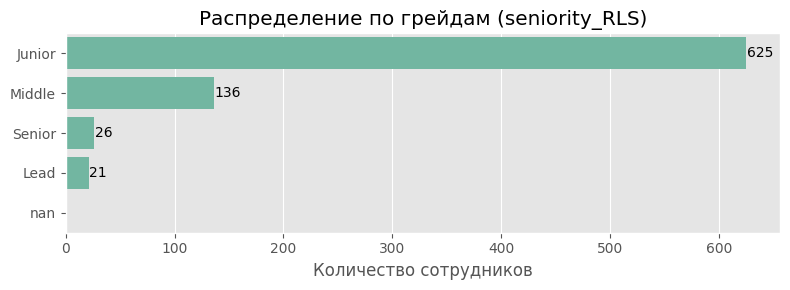

,count,pct
seniority_RLS,,
Junior,625,76.13
Middle,136,16.57
Senior,26,3.17
Lead,21,2.56
NaN,13,1.58


In [8]:
# Маппинг для нормализации seniority_RLS
seniority_map = {
    'Junior': 'Junior',
    'Junior+': 'Junior',
    'Middle': 'Middle',
    'Middle+': 'Middle',
    'Senior': 'Senior',
    'Lead': 'Lead',
    'Lead/Manager': 'Lead',
    'Principal': 'Principal',
    'Head': 'Head',
    'Intern': 'Intern'
}

# Применяем маппинг
df_clean['seniority_RLS'] = df['seniority_RLS'].map(seniority_map)

# Пересчёт распределения
counts = df_clean['seniority_RLS'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Визуализация с подписями
plt.figure(figsize=(8, max(3, len(dist_tbl) * 0.6)))
ax = sns.barplot(
    x=dist_tbl['count'],
    y=dist_tbl.index,
    orient='h',
    order=dist_tbl.index
)
plt.title('Распределение по грейдам (seniority_RLS)')
plt.xlabel('Количество сотрудников')
plt.ylabel('')
for p in ax.patches:
    ax.text(p.get_width() + 0.5, p.get_y() + p.get_height()/2, int(p.get_width()),
            ha='left', va='center')
plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «Грейды» — глубокий разбор и действия

### Что видим (факты)
- **Junior — 76.13% (625)** → подавляющее большинство штата.
- **Middle — 16.57% (136)** и **Senior — 3.17% (26)** → тонкий слой опытных специалистов.
- **Lead — 2.56% (21)** → управленческое звено минимально.
- **NaN — 1.58% (13)** → отсутствие данных, нужно допроверить.

### Интерпретация (риски и гипотезы)
1) **Сильный перекос в сторону Junior** — риски по качеству и скорости выполнения задач, высокая потребность в наставничестве, длинный TtP.  
2) **Уязвимость при потере Senior/Lead** — узкие места в экспертизе, ограниченные возможности масштабировать лучшие практики.  
3) **Низкая «карьерная ёмкость» внутри** — при такой структуре переход из Junior в Middle/Senior может быть затруднён (мало позиций сверху).  
4) Возможен **повышенный отток в 1–2 года** из-за отсутствия внутренних карьерных шагов.

### Где копать глубже
- Доля оттока по грейдам: особенно в сегменте Junior 6–12 и 12–24 мес.  
- Связь грейда с **оценкой ревью**: какая конверсия Junior → Middle, за какой срок.  
- Сравнение грейдов по **производительности, качеству и влиянию на клиентский опыт**.  
- Достаточность наставников: сколько Juniors приходится на 1 Middle/Senior/Lead.

### Метрики контроля
- **Time-to-promotion** из Junior в Middle (цель ≤18 мес).  
- **Доля Middle+Senior+Lead** от штата (целевой рост +5 п.п. за 2 квартала).  
- **Coverage наставничества** — 100% Junior закреплены за Middle/Senior.  
- **Отток Junior в первые 24 мес** (цель: −15% к текущему уровню).

### Конкретные меры
| Проблема | Что делаем | Цель |
|---|---|---|
| Перекос в Junior | Запуск **Junior Acceleration Program**: интенсивные skill-sprints, shadowing, мини-проекты | 30% Juniors в промо pipeline |
| Узкое управленческое звено | Развитие «технических лидов» из Senior/Middle (без формального менеджмента) | +20% наставников за 2 кв. |
| Высокая нагрузка на опытных | Ограничение ratio >10 Juniors на 1 наставника; при превышении — набор Middle/Senior | Ratio ≤8:1 |
| Медленный рост | Прозрачные карьерные карты, промежуточные грейды (Junior+, Middle-) | Средний TtP −20% |

### Системные изменения
1) **Наставничество как KPI** для Middle/Senior — влияние на их бонусную часть.  
2) **Промежуточные ступени** (Junior+, Middle-) для ускорения роста без скачка в полном грейде.  
3) **Целевой найм в верхние грейды** для балансировки структуры и передачи экспертизы.  
4) **Программы удержания** для Senior/Lead (retention-бонусы, проектная автономия).

### Что считаем успехом через 2–3 квартала
- Доля Middle+Senior+Lead выросла с ~22% до 27–30%.  
- Time-to-promotion Junior→Middle сократился на 15–20%.  
- Отток Junior в 6–24 мес снизился на ≥15%.  
- Все Juniors закреплены за наставниками, ratio ≤8:1.

> Итог: структура грейдов — «перевернутая пирамида» с огромным пластом Junior и очень тонким слоем экспертов. Без системного роста Middle/Senior/Lead мы упремся в потолок качества, скорости и удержания.


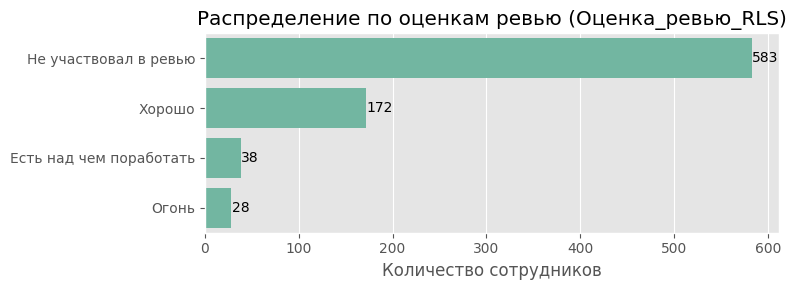

,count,pct
Оценка_ревью_RLS,,
Не участвовал в ревью,583,71.01
Хорошо,172,20.95
Есть над чем поработать,38,4.63
Огонь,28,3.41


In [9]:
# === График 4: Распределение по Оценка_ревью_RLS (сортировка, подписи) ===

# Подсчёт и сортировка
counts = df_clean['Оценка_ревью_RLS'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных для графика
plot_df = dist_tbl.reset_index().rename(columns={'index': 'Оценка_ревью_RLS'})

# Визуализация
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Оценка_ревью_RLS',
    x='count',
    orient='h',
    order=plot_df['Оценка_ревью_RLS']  # порядок уже по убыванию
)
plt.title('Распределение по оценкам ревью (Оценка_ревью_RLS)')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «Оценка ревью» — глубокий разбор и действия

### Что видим (факты)
- **71.01% (583)** — не участвовали в ревью.
- **20.95% (172)** — оценка «Хорошо».
- **4.63% (38)** — «Есть над чем поработать».
- **3.41% (28)** — максимальная оценка «Огонь».

### Интерпретация (риски и гипотезы)
1) **Критически низкий охват ревью** → теряем инструмент системной обратной связи, роста и удержания.
2) **Малая выборка для позитивных/отрицательных оценок** исказывает картину — нет репрезентативности.
3) Возможен **перекос в сторону формального прохождения ревью** (особенно в оценках «Хорошо») без реальной работы над развитием.
4) Отсутствие ревью у большинства может указывать на:
   - формальный процесс без обязательности,
   - нехватку ресурсов HRBP/руководителей,
   - разрыв в культуре обратной связи.

### Где копать глубже
- Кто именно не проходил ревью: по грейдам, стажу, стримам.
- Влияние прохождения ревью на удержание и производительность.
- Доля улучшивших оценку при повторных ревью.
- Наличие «разборов» по оценке «Есть над чем поработать» и последующие карьерные шаги.

### Метрики контроля
- **Coverage ревью** — целевой рост до 90%+ за 2 квартала.
- **Доля оценки «Огонь»** от участвовавших — целевой рост ≥10%.
- **Conversion «Есть над чем поработать» → «Хорошо/Огонь»** за 6 мес — ≥50%.

### Конкретные меры
| Проблема | Что делаем | Цель |
|---|---|---|
| Низкий охват ревью | Сделать ревью обязательным в годовом цикле (с привязкой к бонусам) | Coverage ≥90% |
| Формальность оценок | Ввести калибровочные сессии и примеры поведения для каждой оценки | Рост точности |
| Нет последующих шагов | Для «Есть над чем поработать» — индивидуальный план развития с чёткими KPI | 50%+ улучшений |
| Отсутствие культуры фидбэка | Тренинги для руководителей по проведению качественных ревью | Качество процесса |

### Системные изменения
1) Интеграция прохождения ревью в HRIS с автоматическими напоминаниями.
2) Прозрачная аналитика: лидеры и отстающие подразделения по охвату и качеству.
3) «Best practice» обмен между менеджерами с высокими результатами роста после ревью.
4) Геймификация процесса — признание лучших улучшений.

### Что считаем успехом через 2–3 квартала
- Coverage ревью ≥90%.
- «Огонь» среди прошедших вырос с 3.41% до ≥10%.
- 50%+ сотрудников с «Есть над чем поработать» улучшили оценку.
- Прямая корреляция между ревью и удержанием/производительностью.

> Итог: ревью в текущем виде почти не используется как инструмент развития — это скорее исключение, чем норма. Без повышения охвата и качества мы теряем системную возможность ускорять рост сотрудников и удерживать таланты.


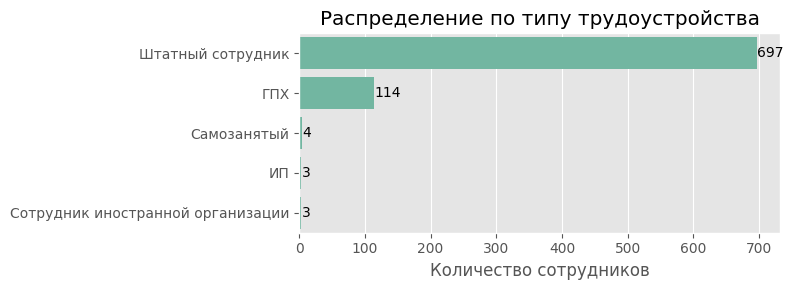

,count,pct
Тип трудоустройства,,
Штатный сотрудник,697,84.90
ГПХ,114,13.89
Самозанятый,4,0.49
ИП,3,0.37
Сотрудник иностранной организации,3,0.37


In [10]:
# === График 5: Распределение по типу трудоустройства (сортировка, подписи) ===

# Подсчёт и сортировка
counts = df_clean['Тип трудоустройства'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных для графика
plot_df = dist_tbl.reset_index().rename(columns={'index': 'Тип трудоустройства'})

# Визуализация
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Тип трудоустройства',
    x='count',
    orient='h',
    order=plot_df['Тип трудоустройства']  # порядок уже по убыванию
)
plt.title('Распределение по типу трудоустройства')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «Тип трудоустройства» — глубокий разбор и действия

### Что видим (факты)
- **84.90% (697)** — штатные сотрудники.
- **13.89% (114)** — работают по ГПХ.
- **<1%** — самозанятые, ИП и сотрудники иностранных организаций (в сумме 10 человек).

### Интерпретация (риски и гипотезы)
1) **Высокая доля штатных сотрудников** говорит о стабильной кадровой структуре и формальном трудоустройстве — позитивный фактор для удержания и вовлеченности.
2) **Существенная доля ГПХ (14%)** может:
   - использоваться для гибких проектных задач,
   - создавать риски для удержания (менее защищены социально),
   - усложнять вовлечение в корпоративную культуру.
3) **Незначительные категории (самозанятые, ИП, иностранные)** могут иметь особые условия и специфические риски (валютные расчёты, налогообложение, правовое поле).

### Где копать глубже
- Стримы и грейды, где выше доля ГПХ — понять, это временная мера или осознанная стратегия.
- Сравнение удержания штатных и ГПХ — разница в % текучести.
- Уровень вовлеченности и участия в корпоративных программах для ГПХ.

### Метрики контроля
- **Доля ГПХ** — целевой диапазон зависит от стратегии: ≤10%, если цель — минимизация временных контрактов.
- **Retention ГПХ vs штатные** — разрыв ≤5 п.п.
- **Вовлеченность ГПХ** в опросах — ≥80% от уровня штатных.

### Конкретные меры
| Проблема | Что делаем | Цель |
|---|---|---|
| Высокая доля ГПХ в ключевых стримах | Пересмотр модели — перевод лучших исполнителей в штат | Снижение доли ГПХ до целевого уровня |
| Риски невовлеченности ГПХ | Программы интеграции и бонусы за участие в проектах | Рост вовлеченности |
| Разрыв в удержании | Предоставить доступ к части льгот и обучения для ГПХ | Выравнивание retention |

### Системные изменения
1) Создать отдельный HR-профиль для ГПХ в HRIS — отслеживать их путь, удержание и вовлеченность.
2) Внедрить «мост» между ГПХ и штатными — регулярные встречи, общие каналы коммуникации.
3) Для редких категорий (ИП, иностранные) — провести аудит рисков и предусмотреть «запасные» схемы взаимодействия.

### Что считаем успехом через 2–3 квартала
- Доля ГПХ приведена к стратегическому диапазону.
- Разрыв в удержании и вовлеченности ≤5 п.п.
- Рост конверсии ГПХ → штатные сотрудники.
- Нет сбоев в проектах из-за нестабильности контрактов.

> Итог: структура занятости в целом стабильная, но доля ГПХ достаточно велика, чтобы влиять на удержание и вовлеченность. Управление этой группой требует целенаправленных HR-интервенций.


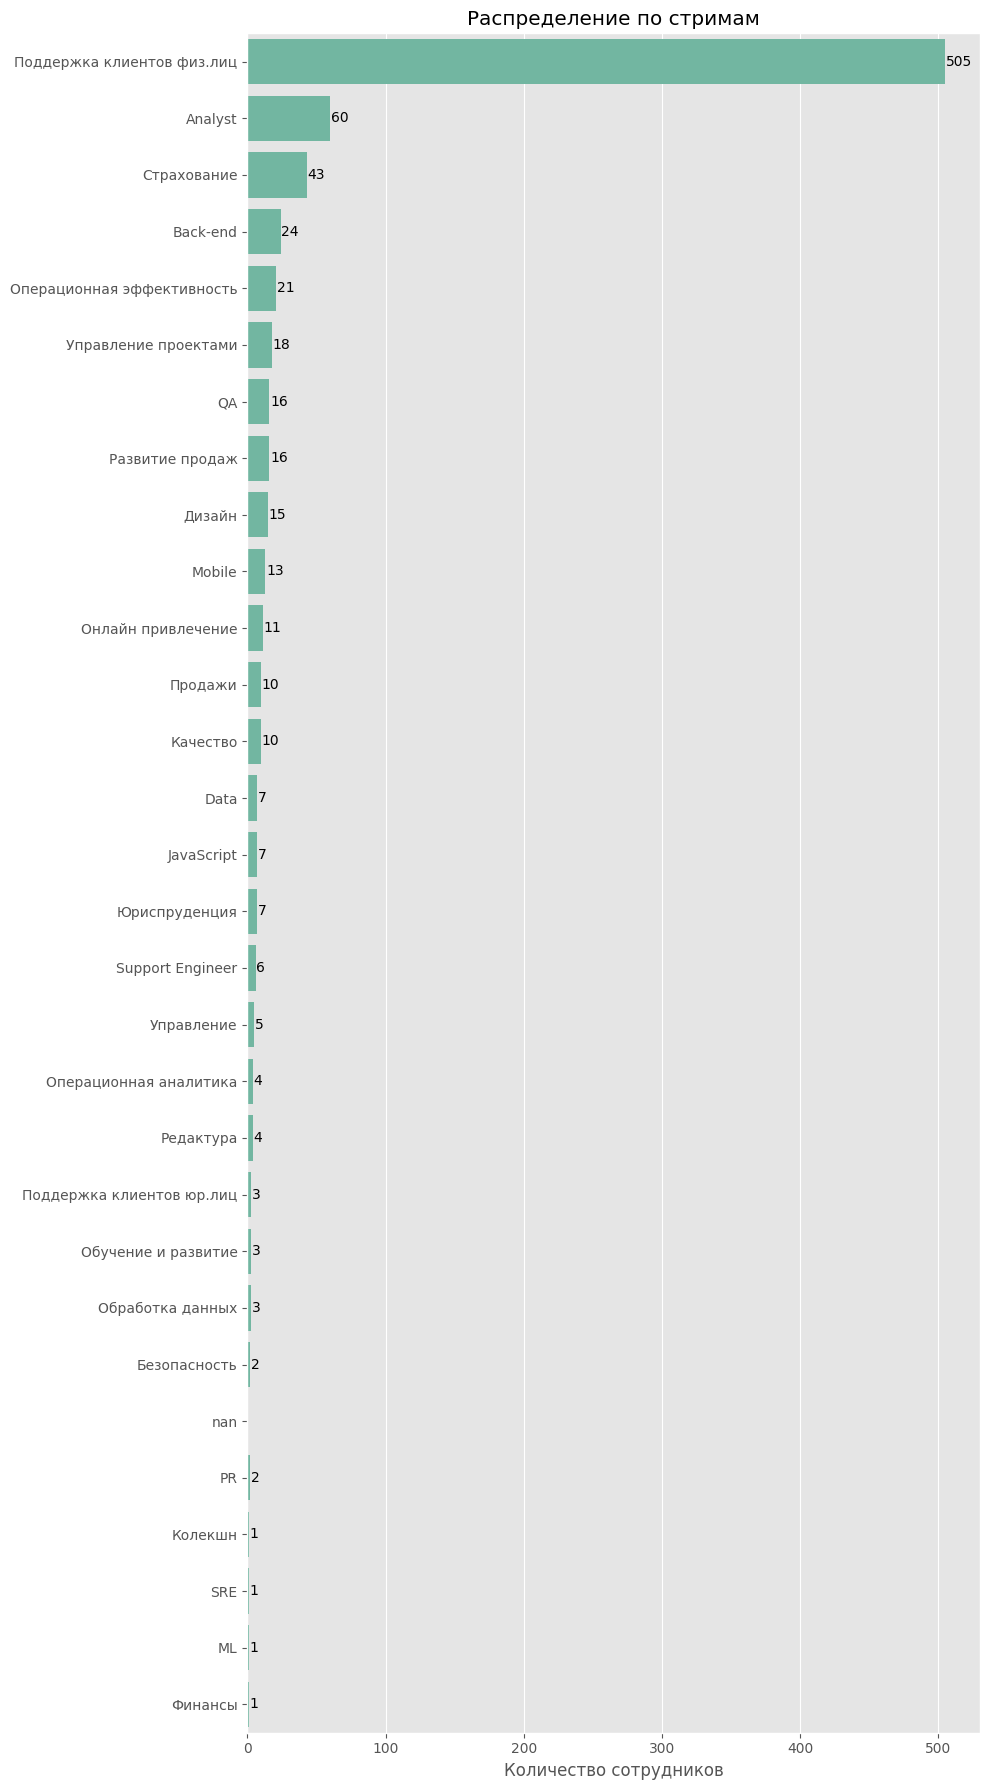

,count,pct
Стрим,,
Поддержка клиентов физ.лиц,505,61.51
Analyst,60,7.31
Страхование,43,5.24
Back-end,24,2.92
Операционная эффективность,21,2.56
Управление проектами,18,2.19
QA,16,1.95
Развитие продаж,16,1.95
Дизайн,15,1.83


In [11]:
# === График 6: Распределение по стримам (сортировка, подписи) ===

# Подсчёт и сортировка
counts = df_clean['Стрим'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных для графика
plot_df = dist_tbl.reset_index().rename(columns={'index': 'Стрим'})

# Визуализация
plt.figure(figsize=(10, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Стрим',
    x='count',
    orient='h',
    order=plot_df['Стрим']
)
plt.title('Распределение по стримам')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «Стрим» — глубокий разбор и действия

### Что видим (факты)
- **61.51% (505)** сотрудников сосредоточены в одном стриме — «Поддержка клиентов физ. лиц».
- Второй по численности сегмент — «Analyst» (7.31%), далее «Страхование» (5.24%).
- Остальные 26 стримов имеют долю ≤3%, значительная фрагментация.
- 2 записи без указания стрима (NaN).

### Интерпретация (риски и гипотезы)
1) **Сильная концентрация в одном стриме** («Поддержка клиентов физ. лиц») означает:
   - высокую зависимость бизнеса от качества и удержания этой группы;
   - потенциальный риск массового увольнения при внешних шоках.
2) **Длинный "хвост" редких стримов** может указывать на:
   - нишевые компетенции, где замена сотрудников сложна и дорога;
   - меньшую видимость для HR и управленцев → риск недоинвестирования.
3) **NaN в данных** — потенциальная проблема качества учета, мешающая точной аналитике.

### Где копать глубже
- Текучесть в «Поддержка клиентов физ. лиц» — особенно в связке со стажем и грейдом.
- Корреляция стрима с типом трудоустройства (ГПХ/штат).
- Уровень оценки ревью по стримам — выявить, где сильнее проседает качество работы.

### Метрики контроля
- **Retention TOP-3 стримов** — ≥90% в квартал.
- **Вовлеченность редких стримов** — ≥85% по опросам.
- **Время замещения вакансий** в стримах с <5% штата — ≤60 дней.

### Конкретные меры
| Проблема | Что делаем | Цель |
|---|---|---|
| Зависимость от одного стрима | Создать кадровый резерв и план переквалификации | Снижение бизнес-рисков |
| Ниша с малой численностью | Персонализированные HR-программы и удержание ключевых специалистов | Уменьшение текучести |
| NaN в данных | Обязательная валидация стрима при вводе в HRIS | Чистота аналитики |

### Системные изменения
1) **HR-мониторинг по стримам** — ежеквартальный отчет с текучестью, вовлеченностью и грейдами.
2) **Кросс-функциональные ротации** между близкими стримами (Analyst ↔ Data, Back-end ↔ SRE/ML).
3) **Карта рисков по стримам** — выделить, где критична потеря даже 1-2 человек.

### Что считаем успехом через 2–3 квартала
- Снижение текучести в «Поддержке клиентов физ. лиц» на ≥5 п.п.
- Сокращение времени закрытия вакансий в нишевых стримах.
- 100% заполненность поля «Стрим» в HRIS.

> Итог: структура стримов крайне асимметрична — необходим приоритетный контроль за массовым стримом поддержки клиентов и целевое развитие кадровых стратегий в нишевых направлениях.


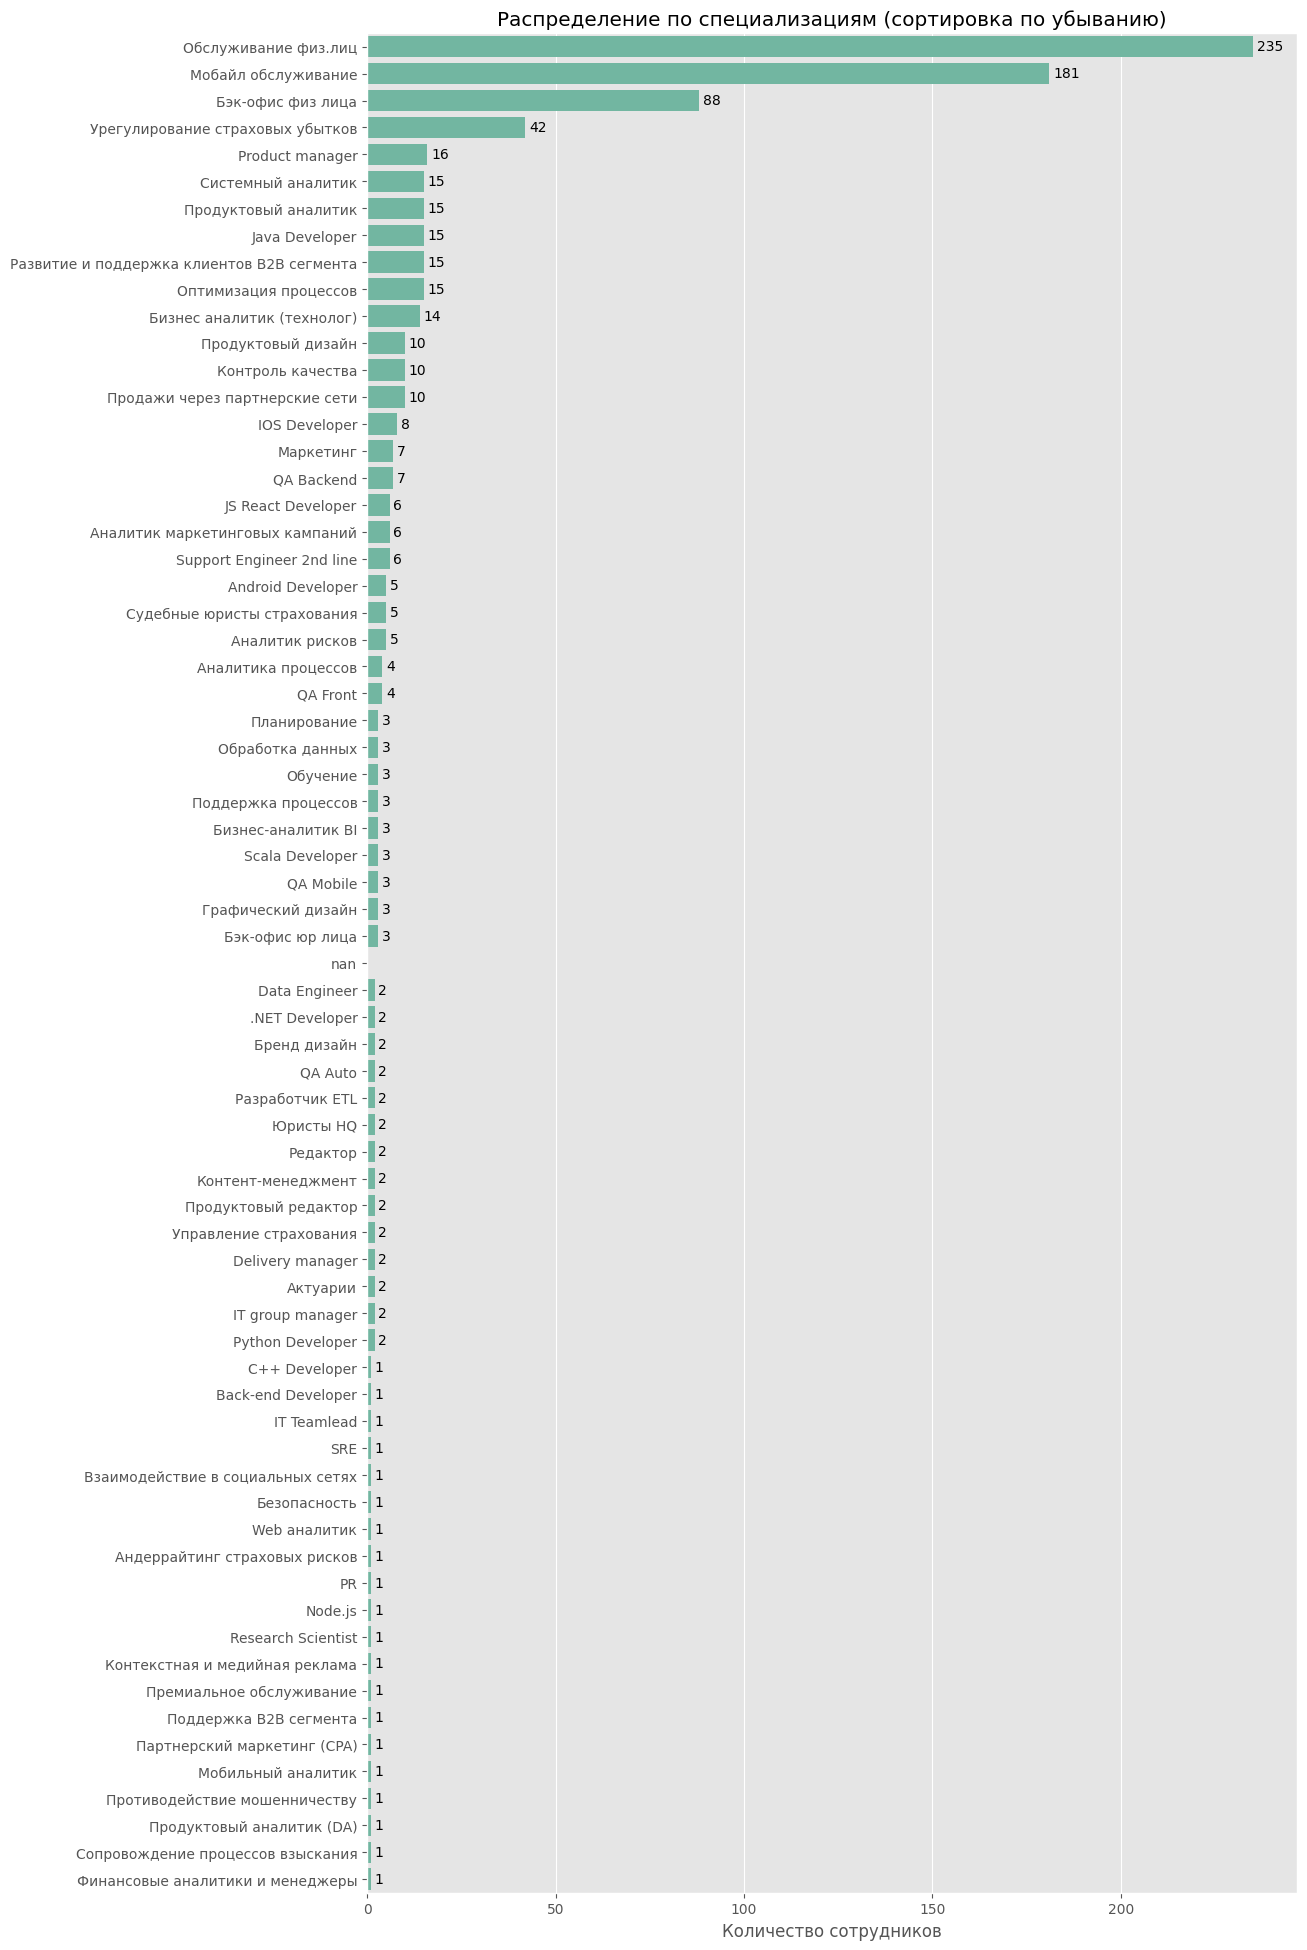

,count,pct
Специализация,,
Обслуживание физ.лиц,235,28.62
Мобайл обслуживание,181,22.05
Бэк-офис физ лица,88,10.72
Урегулирование страховых убытков,42,5.12
Product manager,16,1.95
...,...,...
Мобильный аналитик,1,0.12
Противодействие мошенничеству,1,0.12
Продуктовый аналитик (DA),1,0.12


In [12]:
# === График: Специализация — все категории, сортировка по убыванию + подписи ===

# Подсчёт и сортировка
counts = df_clean['Специализация'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

plot_df = dist_tbl.reset_index().rename(columns={'index': 'Специализация'})

# Визуализация
plt.figure(figsize=(12, max(6, len(plot_df) * 0.35)))
ax = sns.barplot(
    data=plot_df,
    y='Специализация',
    x='count',
    orient='h',
    order=plot_df['Специализация']
)
plt.title('Распределение по специализациям (сортировка по убыванию)')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Добавление подписей на бары
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1,                # немного правее конца бара
            p.get_y() + p.get_height() / 2,
            int(width),
            ha='left', va='center')

plt.show()

# Полная таблица
display(dist_tbl)


## СЕГМЕНТ «Специализации» — анализ структуры и фокусов

### Что видим (факты)
- **Топ-3 специализаций** по численности:
  1. Обслуживание физ. лиц — 235 чел.
  2. Мобайл обслуживание — 181 чел.
  3. Бэк-офис физ. лица — 88 чел.
- Эти три специализации дают **~62%** всей выборки.
- Средние по объёму направления: урегулирование страховых убытков (42 чел.), продуктовые и аналитические роли (15–16 чел. каждая).
- Большой «длинный хвост» из 15+ специализаций с численностью <10 человек.

### Интерпретация (риски и возможности)
1. **Высокая концентрация в операционных ролях** (обслуживание, мобайл, бэк-офис) → бизнес-системы и HR сильно зависят от качества найма и удержания в этих направлениях.
2. **IT/продуктовые и аналитические роли** составляют меньшинство, но являются драйверами цифровой трансформации → риск узких мест при уходе даже одного ключевого специалиста.
3. **Нишевые специализации** (например, маркетинг, QA Backend, SRE, ML) критичны по знанию домена, но уязвимы при текучести из-за малой численности.

### Где копать глубже
- Сравнить текучесть в операционных и IT-направлениях.
- Изучить уровень грейдов и стажа по крупным и нишевым ролям.
- Проверить, как распределены оценки ревью в зависимости от специализации.

### Метрики для мониторинга
- **Текучесть по ТОП-3 специализациям** — контроль не выше среднерыночного уровня.
- **Время закрытия вакансий в нишевых ролях** — ≤60 календарных дней.
- **Доля внутреннего замещения** в ключевых направлениях — ≥30%.

### Рекомендации
| Проблема | Что делаем | Цель |
|---|---|---|
| Зависимость от операционного блока | Разработать долгосрочную стратегию удержания (программы мотивации, гибкие графики, карьерные маршруты) | Снижение текучести и рост вовлеченности |
| Уязвимость нишевых специализаций | Создать программы менторства и передачу знаний | Снижение риска потери уникальных компетенций |
| Слабое представительство продуктовых/IT ролей | Запустить таргетированный найм и внутреннее переобучение | Ускорение цифровых инициатив |

### Долгосрочные меры
1. **Кадровый резерв для операционного блока** — минимум 10% от численности.
2. **Карта компетенций** по всем специализациям с указанием критичных навыков.
3. **Ротация и мультискиллинг** в операционных и смежных ролях для повышения гибкости.

> Итог: кадровая структура смещена в сторону клиентского обслуживания, что требует приоритизации удержания и оптимизации найма, а также защиты узкоспециализированных компетенций в малых командах.


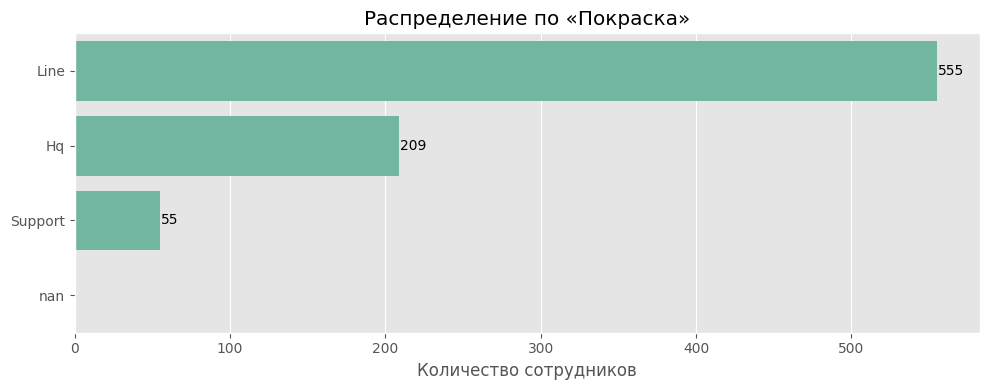

,count,pct
Покраска,,
Line,555,67.60
Hq,209,25.46
Support,55,6.70
NaN,2,0.24


In [13]:
# === График: Распределение по «Покраска» (сортировка, подписи, max→min) ===

# Подсчёт и сортировка
counts = df_clean['Покраска'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных для графика
plot_df = dist_tbl.reset_index().rename(columns={'index': 'Покраска'})

# Визуализация
plt.figure(figsize=(10, max(4, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Покраска',
    x='count',
    orient='h',
    order=plot_df['Покраска']
)
plt.title('Распределение по «Покраска»')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «Покраска» — распределение по функциональным группам

### Что видим (факты)
- **Line** — 555 чел. (67.6%) → основной массив сотрудников.
- **HQ** — 209 чел. (25.5%) → центральный офис и управленческие функции.
- **Support** — 55 чел. (6.7%) → вспомогательные службы.
- Незначительное количество записей с отсутствующими данными — 0.24%.

### Интерпретация (риски и возможности)
1. **Доминирование Line** говорит о высокой операционной нагрузке и зависимости бизнеса от фронтовых команд.
2. **HQ** в 4 раза меньше по численности, что потенциально снижает скорость управленческих изменений при массовых запросах с фронта.
3. **Support** — самая малочисленная группа, но критична для бесперебойной работы Line и HQ.

### Где копать глубже
- Сравнить текучесть в Line, HQ и Support.
- Оценить уровень грейдов и стаж в каждой группе.
- Проверить различия в оценках ревью между группами.

### Метрики для мониторинга
- **Текучесть в Line** — целевой уровень не выше 15% в год.
- **Время реакции HQ и Support на запросы Line** — SLA ≤ 48 часов.
- **Доля сотрудников с грейдом Middle+ в HQ** — ≥50%.

### Рекомендации
| Проблема | Что делаем | Цель |
|---|---|---|
| Высокая нагрузка на Line | Оптимизация процессов и автоматизация рутин | Снижение выгорания и ошибок |
| Невысокая численность HQ | Развивать кросс-функциональные компетенции | Повышение скорости изменений |
| Support как узкое место | Повысить укомплектованность и внедрить KPI по SLA | Устойчивость бизнес-процессов |

### Долгосрочные меры
1. **Программы удержания для Line** — гибкий график, бонусы за качество, карьерные маршруты.
2. **Мультискиллинг HQ** для гибкого перераспределения ресурсов.
3. **Автоматизация поддержки** через сервис-деск и чат-боты.

> Итог: структура «Покраски» типична для операционно ориентированного бизнеса — основная нагрузка на фронтовых сотрудников, при этом поддержка и HQ должны быть усилены инструментами, позволяющими быстро реагировать на запросы и предотвращать перегрузку.


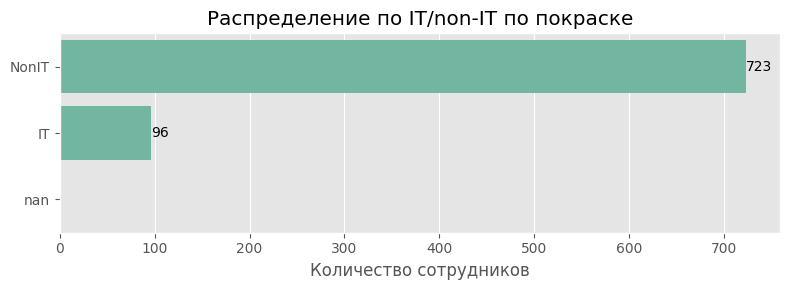

,count,pct
IT/non-IT по покраске,,
NonIT,723,88.06
IT,96,11.69
NaN,2,0.24


In [14]:
# === График: Распределение по IT/non-IT по покраске (max→min, подписи) ===

# Подсчёт и сортировка
counts = df_clean['IT/non-IT по покраске'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных
plot_df = dist_tbl.reset_index().rename(columns={'index': 'IT/non-IT по покраске'})

# Визуализация
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='IT/non-IT по покраске',
    x='count',
    orient='h',
    order=plot_df['IT/non-IT по покраске']
)
plt.title('Распределение по IT/non-IT по покраске')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «IT / non-IT по покраске»

### Что видим (факты)
- **NonIT** — 723 чел. (88.06%) → подавляющее большинство сотрудников.
- **IT** — 96 чел. (11.69%) → относительно небольшой, но стратегически важный сегмент.
- Отсутствующие данные — 0.24%.

### Интерпретация (риски и возможности)
1. **Дисбаланс в структуре**: IT-специалисты составляют менее 12% персонала, что может ограничивать скорость цифровой трансформации.
2. **NonIT** сегмент — это основная операционная сила, которая требует цифровых инструментов и автоматизации, но зависима от ресурсов IT.
3. Возможен риск перегрузки IT-команд при масштабировании процессов, особенно при большом фронте задач от NonIT.

### Где копать глубже
- Изучить соотношение IT и NonIT в ключевых стримах и подразделениях.
- Оценить количество IT-специалистов на 100 сотрудников NonIT (коэффициент технологической поддержки).
- Проверить текучесть и вовлечённость в IT-сегменте отдельно.

### Метрики для мониторинга
- **IT coverage ratio**: количество IT на 100 NonIT → целевой уровень ≥15.
- **SLA IT-поддержки** — среднее время решения задач ≤ 5 рабочих дней.
- **Доля IT Middle+** — ≥70% для обеспечения экспертизы.

### Рекомендации
| Проблема | Что делаем | Цель |
|---|---|---|
| Недостаток IT-ресурсов | Планомерное увеличение IT штата или привлечение внешних команд | Сокращение бэклога и времени реализации |
| Зависимость NonIT от IT | Развитие no-code инструментов в NonIT | Снижение нагрузки на IT |
| Риски при росте запросов | Внедрить приоритизацию задач по бизнес-ценности | Ускорение реализации критичных задач |

### Долгосрочные меры
1. **IT-академия для NonIT** — обучение базовым цифровым инструментам.
2. **Автоматизация типовых запросов** в IT (чек-листы, базы знаний, чат-боты).
3. **Балансировка IT/NonIT** — план набора и ротации специалистов в зависимости от стратегии роста.

> Итог: Доля IT относительно невелика, что типично для крупных операционных структур, но для обеспечения гибкости и скорости изменений потребуется системная работа по наращиванию IT-компетенций и оптимизации взаимодействия между сегментами.


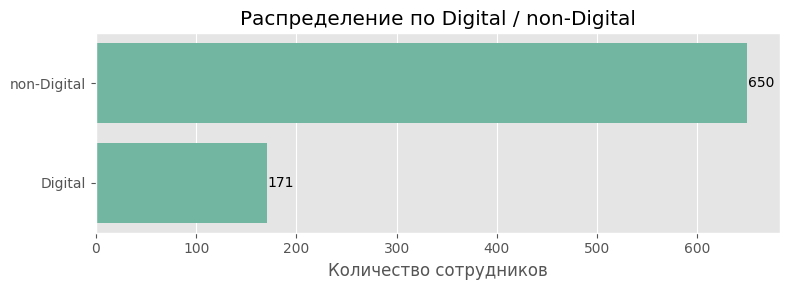

,count,pct
Digital/ non-Digital,,
non-Digital,650,79.17
Digital,171,20.83


In [15]:
# === График: Digital / non-Digital (max→min, подписи) ===

# Подсчёт и сортировка
counts = df_clean['Digital/ non-Digital'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных
plot_df = dist_tbl.reset_index().rename(columns={'index': 'Digital/ non-Digital'})

# Визуализация
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Digital/ non-Digital',
    x='count',
    orient='h',
    order=plot_df['Digital/ non-Digital']
)
plt.title('Распределение по Digital / non-Digital')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Таблица
display(dist_tbl)


## СЕГМЕНТ «Digital / non-Digital»

### Что видим (факты)
- **non-Digital** — 650 чел. (79.17%) → почти 4 из 5 сотрудников работают в недиджитал-направлениях.
- **Digital** — 171 чел. (20.83%) → каждый пятый сотрудник вовлечён в цифровые продукты и сервисы.

### Интерпретация (риски и возможности)
1. **Высокая доля non-Digital** указывает на сильную операционную основу компании, но также на зависимость от процессов, которые могут быть оптимизированы через цифровые инструменты.
2. Digital-направление — ключевой драйвер роста и инноваций, но сейчас оно представлено сравнительно небольшой группой специалистов.
3. Потенциал роста Digital-сегмента особенно важен для повышения эффективности и снижения операционных затрат.

### Где копать глубже
- Анализ распределения Digital-сотрудников по стримам и грейдам.
- Оценка вклада Digital в финансовые и операционные KPI.
- Сравнение текучести кадров между Digital и non-Digital сегментами.

### Метрики для мониторинга
- **Digital penetration rate** = Digital / Общее число сотрудников → целевой уровень ≥30%.
- **Доля Digital Middle+** — ≥65% для ускорения внедрения инноваций.
- **Time-to-Market** для Digital-продуктов.

### Рекомендации
| Проблема | Что делаем | Цель |
|---|---|---|
| Недостаточная доля Digital | Постепенное наращивание Digital-команд | Увеличение покрытия цифровыми продуктами |
| Ограниченная экспертиза | Обучение non-Digital сотрудников цифровым навыкам | Сокращение зависимости от Digital-штата |
| Возможная изоляция Digital-команд | Кросс-функциональные проекты с участием non-Digital | Повышение синергии и скорости изменений |

### Долгосрочные меры
1. **Digital Upskilling Program** — системное обучение сотрудников всех сегментов цифровым навыкам.
2. **Интеграция Digital в операционные процессы** — чтобы Digital не работал в отрыве, а улучшал core-процессы.
3. **KPI по цифровой трансформации** — закрепить на уровне подразделений.

> Итог: Несмотря на то, что Digital-сегмент пока занимает только пятую часть штата, его потенциал для ускорения трансформации и снижения затрат огромен. Ключевой фокус — рост команды и интеграция digital-подходов в ежедневную операционную деятельность.


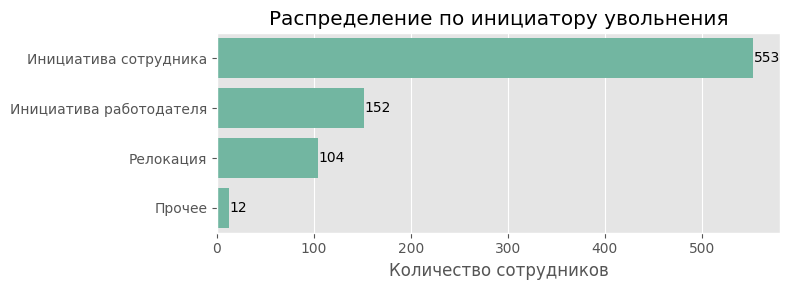

,count,pct
Инициатор увольнения_RLS,,
Инициатива сотрудника,553,67.36
Инициатива работодателя,152,18.51
Релокация,104,12.67
Прочее,12,1.46


In [16]:
# === График: Инициатор увольнения_RLS — сортировка по убыванию + подписи ===

# Подсчёт и сортировка
counts = df_clean['Инициатор увольнения_RLS'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

# Подготовка данных
plot_df = dist_tbl.reset_index().rename(columns={'index': 'Инициатор увольнения_RLS'})

# Визуализация
plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Инициатор увольнения_RLS',
    x='count',
    orient='h',
    order=plot_df['Инициатор увольнения_RLS']
)
plt.title('Распределение по инициатору увольнения')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи на барах
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Полная таблица
display(dist_tbl)


## СЕГМЕНТ «Инициатор увольнения»

### Что видим (факты)
- **Инициатива сотрудника** — 553 чел. (67.36%) → 2/3 всех увольнений инициируются самими сотрудниками.
- **Инициатива работодателя** — 152 чел. (18.51%).
- **Релокация** — 104 чел. (12.67%), значимый фактор внешнего характера.
- **Прочее** — 12 чел. (1.46%).

### Интерпретация (риски и возможности)
1. **Высокая доля добровольных увольнений** говорит о проблемах удержания, возможно — в мотивации, условиях труда или карьерных перспективах.
2. **Релокация** — почти каждое восьмое увольнение, что может быть связано с внешними социально-экономическими факторами, которые компания напрямую изменить не может.
3. **Инициатива работодателя** на уровне ~18% может указывать на относительно умеренную долю корректировок штата по результатам перфоманса или реструктуризации.

### Где копать глубже
- Сегментация причин увольнений по грейдам и стажу.
- Анализ eNPS/удовлетворённости среди сотрудников, которые находятся в зоне риска ухода.
- Сравнение показателей текучести по стримам, особенно там, где выше добровольные уходы.

### Метрики для мониторинга
- **Voluntary Turnover Rate** = Инициатива сотрудника / Общее число увольнений.
- **Retention Rate** по ключевым позициям.
- **Early Attrition** — доля увольнений в первые 12 мес.

### Рекомендации
| Проблема | Что делаем | Цель |
|---|---|---|
| Высокий уровень добровольных увольнений | Провести exit-интервью и анализ обратной связи | Выявление ключевых причин ухода |
| Потеря сотрудников на ранних сроках | Улучшение адаптации и наставничества | Повышение удержания в первые 12 мес |
| Риски релокации | Гибридные и удалённые форматы работы | Сокращение потерь по географическим причинам |

### Долгосрочные меры
1. **Программа удержания ключевых специалистов** — индивидуальные карьерные треки и дополнительные льготы.
2. **Системный feedback-loop** — ежеквартальные опросы удовлетворённости и обсуждение планов развития с сотрудниками.
3. **Predictive HR Analytics** — прогнозирование риска увольнения на основе данных (срок работы, грейд, оценки, вовлечённость).

> Итог: Преобладание инициативы сотрудника в увольнениях — это сигнал к фокусировке на удержании и повышении ценности работы внутри компании. Стратегия должна сочетать улучшение условий и развитие долгосрочных карьерных перспектив.


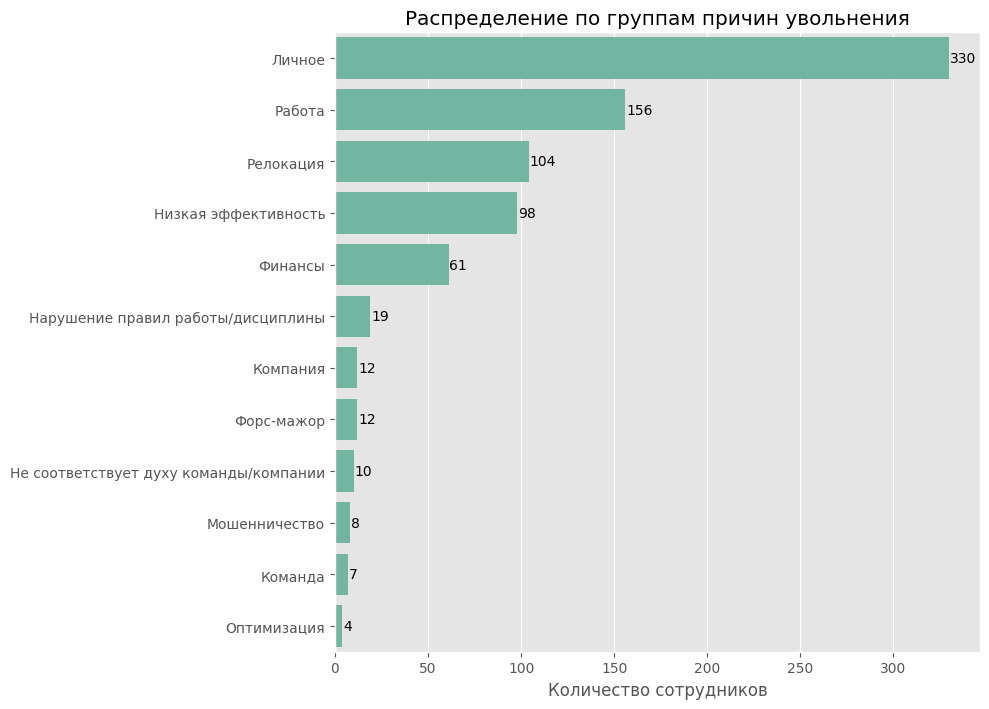

,count,pct
Группа причин увольнений_RLS,,
Личное,330,40.19
Работа,156,19.00
Релокация,104,12.67
Низкая эффективность,98,11.94
Финансы,61,7.43
Нарушение правил работы/дисциплины,19,2.31
Компания,12,1.46
Форс-мажор,12,1.46
Не соответствует духу команды/компании,10,1.22


In [17]:
# === График: Группа причин увольнений_RLS — самые большие сверху ===

# Подсчёт и сортировка
counts = df_clean['Группа причин увольнений_RLS'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

plot_df = dist_tbl.reset_index().rename(columns={'index': 'Группа причин увольнений_RLS'})

# Визуализация (передаём порядок от большего к меньшему)
plt.figure(figsize=(10, max(4, len(plot_df) * 0.6)))
ax = sns.barplot(
    data=plot_df,
    y='Группа причин увольнений_RLS',
    x='count',
    orient='h',
    order=plot_df['Группа причин увольнений_RLS']  # уже отсортировано по убыванию
)
plt.title('Распределение по группам причин увольнения')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи на барах
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Полная таблица
display(dist_tbl)


## СЕГМЕНТ «Группа причин увольнений»

### Что видим (факты)
- **Личное** — 330 чел. (40.19%) → доминирующая категория, почти половина всех случаев.
- **Работа** — 156 чел. (19.00%), отражает недовольство условиями, задачами, организацией процессов.
- **Релокация** — 104 чел. (12.67%), подтверждает тренд, ранее выделенный по инициативам увольнения.
- **Низкая эффективность** — 98 чел. (11.94%), основной фактор увольнений по инициативе работодателя.
- **Финансы** — 61 чел. (7.43%), указывает на несоответствие ожиданий по зарплате.
- Мелкие, но критичные категории: нарушение дисциплины (2.31%), несоответствие культуре (1.22%), мошенничество (0.97%).

### Интерпретация
1. **Личное и работа** в сумме дают почти 60% всех причин — это значит, что значительная часть текучести может быть связана с субъективным восприятием и управляемыми внутрикомпаний факторами.
2. **Релокация** остаётся стабильным внешним фактором.
3. **Низкая эффективность** на уровне ~12% — индикатор необходимости раннего выявления и поддержки сотрудников с падающей продуктивностью.
4. **Финансовые причины** на уровне 7% — стоит анализировать конкурентоспособность компенсаций.
5. **Дисциплина, мошенничество, культура** — хоть и низкая доля, но высокий репутационный риск.

### Где копать глубже
- Кросс-анализ «причины увольнения» с **грейдом, стажем, стримом**.
- Сопоставление «работа» и «финансы» с eNPS, результатами ревью.
- Анализ динамики «низкой эффективности» за периоды.

### Метрики для мониторинга
- Доля «личных» причин от общего числа увольнений.
- Доля «низкой эффективности» по подразделениям.
- % увольнений по дисциплинарным причинам.

### Рекомендации
| Проблема | Действия | Цель |
|---|---|---|
| Высокая доля «личных» причин | Введение программ work-life balance, гибких графиков | Снижение стресса и конфликтов вне работы |
| Причины «работа» | Аудит процессов, улучшение условий и инструментов | Повышение вовлечённости |
| Низкая эффективность | Внедрение систем раннего предупреждения и перфоманс-коучинга | Снижение увольнений по результатам |
| Финансы | Регулярный пересмотр грейдов и компенсаций | Конкурентоспособность на рынке труда |
| Нарушение дисциплины/мошенничество | Усиление HR compliance и обучения | Снижение репутационных рисков |

### Долгосрочные меры
1. **Employee Journey Map** для выявления точек фрустрации на разных стадиях работы.
2. **Predictive performance scoring** — прогнозирование падения эффективности до критического уровня.
3. **Культура обратной связи** — регулярные one-to-one, опросы вовлечённости, командные ретроспективы.

> Итог: Почти половина увольнений вызвана «личными» причинами, что требует гибкого подхода к удержанию и балансу между рабочими и личными потребностями сотрудников. «Работа» и «финансы» — управляемые зоны влияния HR и бизнеса, а «низкая эффективность» требует внедрения систем поддержки до наступления кризисной точки.


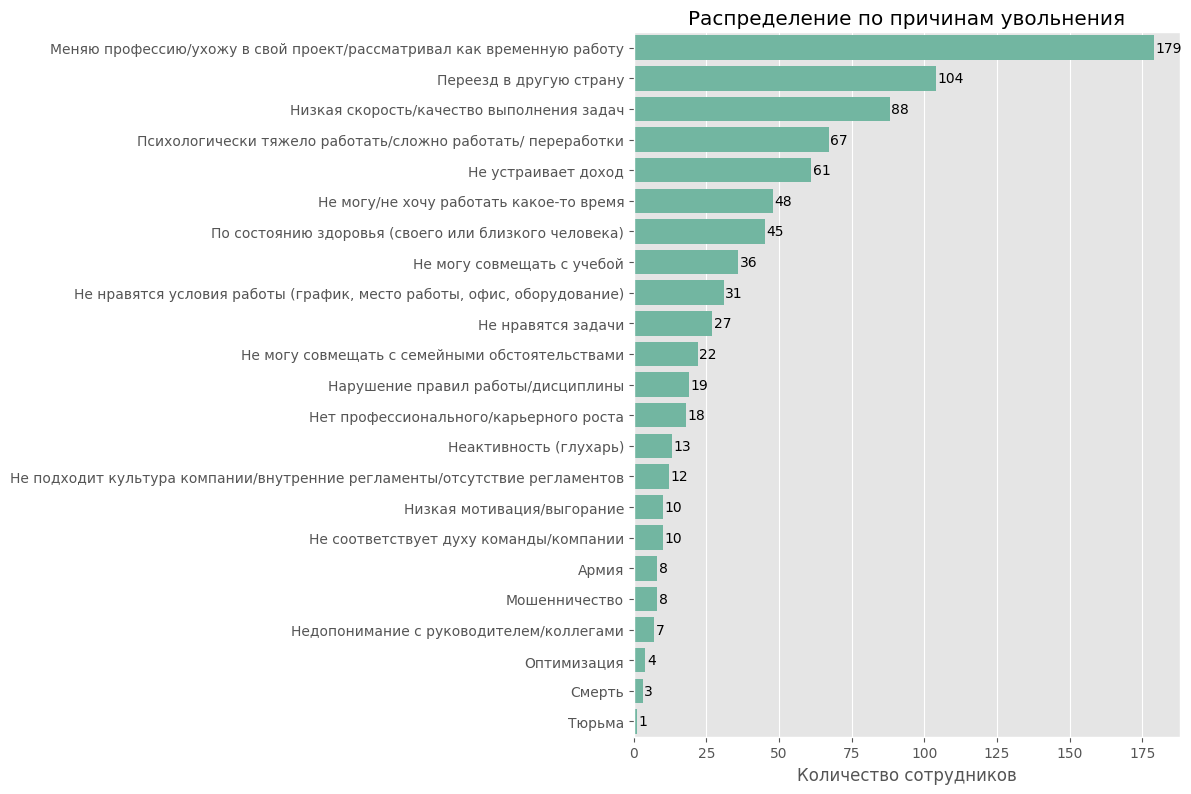

,count,pct
Причина увольнения_RLS,,
Меняю профессию/ухожу в свой проект/рассматривал как временную работу,179,21.80
Переезд в другую страну,104,12.67
Низкая скорость/качество выполнения задач,88,10.72
Психологически тяжело работать/сложно работать/ переработки,67,8.16
Не устраивает доход,61,7.43
Не могу/не хочу работать какое-то время,48,5.85
По состоянию здоровья (своего или близкого человека),45,5.48
Не могу совмещать c учебой,36,4.38
"Не нравятся условия работы (график, место работы, офис, оборудование)",31,3.78


In [18]:
# === График: Причина увольнения_RLS — сортировка по убыванию, подписи ===

# Подсчёт и сортировка
counts = df_clean['Причина увольнения_RLS'].value_counts(dropna=False)
dist_tbl = (
    counts.to_frame('count')
    .assign(pct=lambda t: (t['count'] / len(df_clean) * 100).round(2))
    .sort_values('count', ascending=False)
)

plot_df = dist_tbl.reset_index().rename(columns={'index': 'Причина увольнения_RLS'})

# Визуализация (самые большие категории сверху)
plt.figure(figsize=(12, max(6, len(plot_df) * 0.35)))
ax = sns.barplot(
    data=plot_df,
    y='Причина увольнения_RLS',
    x='count',
    orient='h',
    order=plot_df['Причина увольнения_RLS']
)
plt.title('Распределение по причинам увольнения')
plt.xlabel('Количество сотрудников')
plt.ylabel('')

# Подписи
for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height() / 2, int(w),
            ha='left', va='center')

plt.tight_layout()
plt.show()

# Полная таблица
display(dist_tbl)


## СЕГМЕНТ «Причина увольнения_RLS»

### Ключевые наблюдения
1. **Лидирующая причина** — *смена профессии / уход в свой проект / временная работа* (21.8%). Это отражает карьерную мобильность и восприимчивость сотрудников к смене сферы.
2. **Релокация за границу** (12.67%) — стабильный внешний фактор, не зависящий от внутренних процессов.
3. **Производственные факторы**:
   - Низкая скорость/качество выполнения задач (10.72%) — индикатор дефицита навыков, слабой адаптации или неверного подбора персонала.
   - Психологическая нагрузка и переработки (8.16%) — сигнал о перегрузке команд и дисбалансе в workload.
4. **Финансовый фактор** — неудовлетворённость доходом (7.43%).
5. **Временные и жизненные обстоятельства**: невозможность совмещать с учёбой (4.38%) и семейными обстоятельствами (2.68%), здоровье (5.48%).
6. **Низкая мотивация / выгорание** (1.22%) + отсутствие роста (2.19%) — признаки дефицита карьерных возможностей.
7. **Критические репутационные риски**: дисциплинарные нарушения (2.31%), мошенничество (0.97%), конфликты с руководством (0.85%).

### Интерпретация
- **Карьерная турбулентность** (смена профессии, релокация) составляет ~34% случаев — зона частично вне контроля HR, но можно влиять через гибкость карьерных треков.
- **Условия и нагрузка** в сумме с "не нравится работа" и "не нравятся задачи" дают ~15% — зона управляемых улучшений.
- **Низкая эффективность** (10.72%) напрямую коррелирует с увольнениями по инициативе работодателя и требует интеграции в систему раннего предупреждения.
- **Финансы** остаются в топ-5 причин, указывая на необходимость периодического пересмотра компенсаций.

### Рекомендации
| Проблемная зона | Предлагаемые действия | Цель |
|---|---|---|
| Смена профессии / уход в проекты | Разработка внутренних стартап-программ, возможность перехода в другие отделы | Удержание талантов внутри компании |
| Низкая эффективность | Введение обязательных адаптационных треков, наставничество, регулярные оценки прогресса | Повышение результативности |
| Перегрузка / психологическая тяжесть | Пересмотр норм нагрузки, внедрение систем распределения задач | Снижение стресса и выгорания |
| Неудовлетворённость доходом | Регулярный salary review, прозрачная грейдовая система | Конкурентоспособность на рынке |
| Отсутствие карьерного роста | Карьерные карты, образовательные программы | Повышение вовлечённости |

### Долгосрочные инициативы
1. **HR-аналитика текучести по когорте найма** — отслеживать, через какой срок сотрудники уходят по каждой причине.
2. **Система ранних сигналов**: сочетание KPI, eNPS, перегрузок и отпусков как индикаторов риска ухода.
3. **Адаптация EVP (Employee Value Proposition)** для разных поколений сотрудников (Z, Y, X).

> Итог: Более 1/5 увольнений связано с желанием сменить профессию или уйти в свой проект, что требует гибкости в карьерных сценариях. Вторая крупная группа — производственные и эмоциональные факторы, которые можно значительно снизить через улучшение адаптации, баланса нагрузки и системного роста сотрудников.


# План углублённого исследования (по сегментам)

**A. Грейд × Тип трудоустройства**
- Вопрос: влияет ли формат договора на профиль увольняющихся по грейдам?
- Что считаем: кросс-таблица (count / % по строкам / % по столбцам), топ-выводы.

**B. Охват ревью по стажу и грейдам**
- Вопрос: кто именно «проваливается» в 71% без ревью?
- Что считаем: `Оценка_ревью_RLS` × укрупнённые окна стажа (0–6, 6–12, 12–24, 24–60, 60+) и × грейд.

**C. Стрим «Analyst» — портрет уходящих**
- Вопрос: почему уходит 60 аналитиков?
- Что считаем: распределения по стажу, грейду, инициатору, группам и конкретным причинам; сравнение с остальными стримами.

**D. Блок HQ (209 чел.) + УС-уровни**
- Вопрос: что за профиль HQ и как распределён `УС - Уровень 5`?
- Что считаем: HQ vs Line/Support по грейдам, стажу, ревью, причинам; детально `УС - Уровень 5`.

**E. Увольнения по инициативе работодателя (152 чел.)**
- Вопрос: кто это? (грейды/стаж/стримы/причины)
- Что считаем: срезы и топ-категории (ожидаемо «Низкая эффективность», дисциплина, оптимизация).

**F. Релокация (104 чел.)**
- Вопрос: какие роли/грейды релокируются? (особенно IT/Digital)
- Что считаем: разрезы по грейду, стриму, Digital/IT, стажу.

**G. Детализация групп «Личное» и «Работа»**
- Вопрос: какие точные под-причины внутри групп?
- Что считаем: топ-подкатегории `Причина увольнения_RLS` в обеих группах, разрез по стажу/грейду.

**H. Сводная карта рисков и быстрых мер**
- Соберём ключевые инсайты из A–G и дадим целевые интервенции + метрики.


## A) Грейд × Тип трудоустройства
**Зачем:** увидеть, в каких сочетаниях грейда (Junior/Middle/…) и типа договора (штат, ГПХ, самозанятый и т. д.) скапливается основной отток — чтобы точечно наводить меры.

**На какой вопрос отвечает:**
- Какие грейды чаще всего уходят при каждом формате договора?
- Какие форматы договора сильнее всего «несут» отток внутри каждого грейда?
- Какие пары (например, Junior × ГПХ) дают непропорционально большой вклад и требуют приоритета (компенсации, онбординг, ревью)?


In [19]:
# === A) Грейд × Тип трудоустройства: count, % по строкам, % по столбцам ===

# Аккуратная копия
t = df_clean.copy()

# Убедимся в желаемом порядке грейдов (если категориальная колонка уже упорядочена — порядок сохранится)
grade_order = ["Junior", "Middle", "Senior", "Lead", "Principal", "Head"]
if "seniority_RLS" in t.columns:
    # приводим к категориальному типу с упорядочением (NaN останутся как есть)
    t["seniority_RLS"] = t["seniority_RLS"].astype("category")
    t["seniority_RLS"] = t["seniority_RLS"].cat.set_categories(grade_order, ordered=True)

# 1) Абсолюты
ct_count = pd.crosstab(
    t["seniority_RLS"], t["Тип трудоустройства"],
    dropna=False
).fillna(0).astype(int)

# 2) % по строкам (внутри грейда)
ct_rowpct = (ct_count.div(ct_count.sum(axis=1).replace(0, pd.NA), axis=0) * 100).round(2)

# 3) % по столбцам (внутри типа договора)
ct_colpct = (ct_count.div(ct_count.sum(axis=0).replace(0, pd.NA), axis=1) * 100).round(2)

display(pd.DataFrame({"": ["Абсолюты по грейду × типу договора"]}))
display(ct_count)
display(pd.DataFrame({"": ["Доли внутри грейда (row %)"]}))
display(ct_rowpct)
display(pd.DataFrame({"": ["Доли внутри типа договора (col %)"]}))
display(ct_colpct)

# Авто-выводы (коротко): какие ячейки дают максимальный вклад
top_cells = (
    ct_count.stack()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
    .reset_index()
    .rename(columns={"seniority_RLS": "Грейд", "Тип трудоустройства": "Тип договора"})
)
display(pd.DataFrame({"": ["Топ-10 сочетаний по количеству"]}))
display(top_cells)

# Короткая текстовая интерпретация
total = len(t)
jun_abs = ct_count.loc["Junior"].sum() if "Junior" in ct_count.index else 0
mid_abs  = ct_count.loc["Middle"].sum() if "Middle" in ct_count.index else 0
sen_abs  = ct_count.loc["Senior"].sum() if "Senior" in ct_count.index else 0
lead_abs = ct_count.loc["Lead"].sum()   if "Lead"   in ct_count.index else 0

msg = (
    f"Всего записей: {total}. Из них по грейдам — Junior: {jun_abs}, Middle: {mid_abs}, "
    f"Senior: {sen_abs}, Lead: {lead_abs}. См. таблицы выше для распределений по формату договора."
)
print(msg)


,
0,Абсолюты по грейду × типу договора


Тип трудоустройства,ГПХ,ИП,Самозанятый,Сотрудник иностранной организации,Штатный сотрудник
seniority_RLS,,,,,
NaN,7,0,0,0,6
Junior,90,0,4,0,531
Middle,11,2,0,3,120
Senior,3,1,0,0,22
Lead,3,0,0,0,18
Principal,0,0,0,0,0
Head,0,0,0,0,0


,
0,Доли внутри грейда (row %)


Тип трудоустройства,ГПХ,ИП,Самозанятый,Сотрудник иностранной организации,Штатный сотрудник
seniority_RLS,,,,,
NaN,53.846154,0.0,0.0,0.0,46.153846
Junior,14.4,0.0,0.64,0.0,84.96
Middle,8.088235,1.470588,0.0,2.205882,88.235294
Senior,11.538462,3.846154,0.0,0.0,84.615385
Lead,14.285714,0.0,0.0,0.0,85.714286
Principal,<NA>,<NA>,<NA>,<NA>,<NA>
Head,<NA>,<NA>,<NA>,<NA>,<NA>


,
0,Доли внутри типа договора (col %)


Тип трудоустройства,ГПХ,ИП,Самозанятый,Сотрудник иностранной организации,Штатный сотрудник
seniority_RLS,,,,,
NaN,6.14,0.00,0.0,0.0,0.86
Junior,78.95,0.00,100.0,0.0,76.18
Middle,9.65,66.67,0.0,100.0,17.22
Senior,2.63,33.33,0.0,0.0,3.16
Lead,2.63,0.00,0.0,0.0,2.58
Principal,0.00,0.00,0.0,0.0,0.00
Head,0.00,0.00,0.0,0.0,0.00


,
0,Топ-10 сочетаний по количеству


,Грейд,Тип договора,count
0,Junior,Штатный сотрудник,531
1,Middle,Штатный сотрудник,120
2,Junior,ГПХ,90
3,Senior,Штатный сотрудник,22
4,Lead,Штатный сотрудник,18
5,Middle,ГПХ,11
6,NaN,ГПХ,7
7,NaN,Штатный сотрудник,6
8,Junior,Самозанятый,4
9,Middle,Сотрудник иностранной организации,3


Всего записей: 821. Из них по грейдам — Junior: 625, Middle: 136, Senior: 26, Lead: 21. См. таблицы выше для распределений по формату договора.


## Грейд × Тип трудоустройства — короткие выводы

- **Основной пул — джуны на штате:** 531 человек (~85% всех Junior). Это главный источник оттока.
- **Второй по размеру — джуны на ГПХ:** 90 человек (~14% Junior). Формат договора, вероятно, ускоряет уход.
- **Middle — в основном штат:** ~88% штат, ГПХ редок (~8%).
- **Senior/Lead — похожий профиль:** ~85% штат, ~11–14% ГПХ.
- **Самозанятые — единицы:** всего 4 человека, все Junior.
- **Иностранные организации — штучно:** 3 случая (Middle).
- **Риск-зона:** связка **Junior + ГПХ** — требует проверки условий/вовлечённости (онбординг, график, нагрузка, прозрачность перехода на штат).


## B) Охват ревью по стажу и грейдам
**Зачем:** понять, где и у кого сотрудники чаще всего остаются без регулярной обратной связи и оценки — частая причина ранних уходов.

**На какой вопрос отвечает:**
- У каких сочетаний «стаж × грейд» чаще всего нет ревью?
- Какие группы дают наибольший вклад в общую долю «без ревью»?
- Какие группы первыми нужно подключать к регулярным встречам с руководителем и плану адаптации/поддержки?


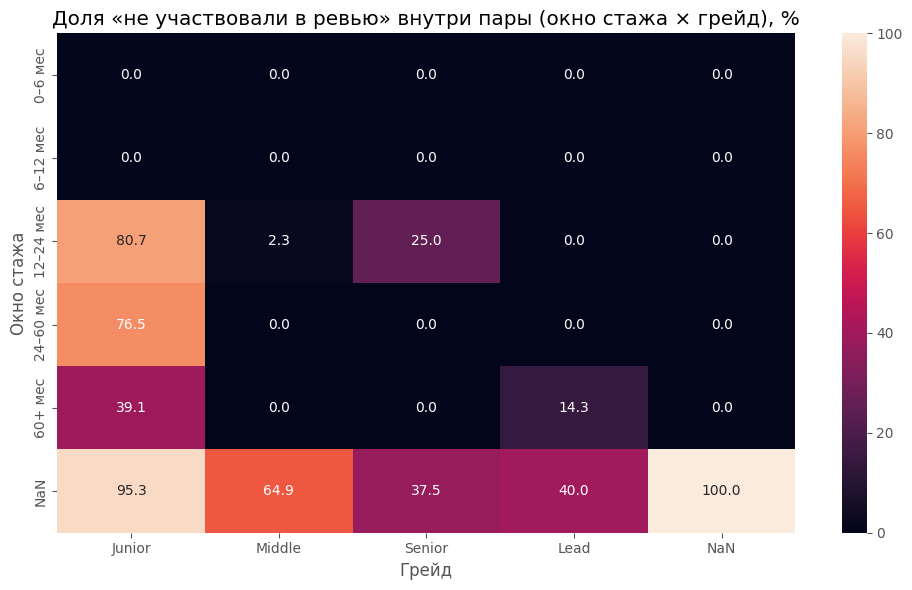

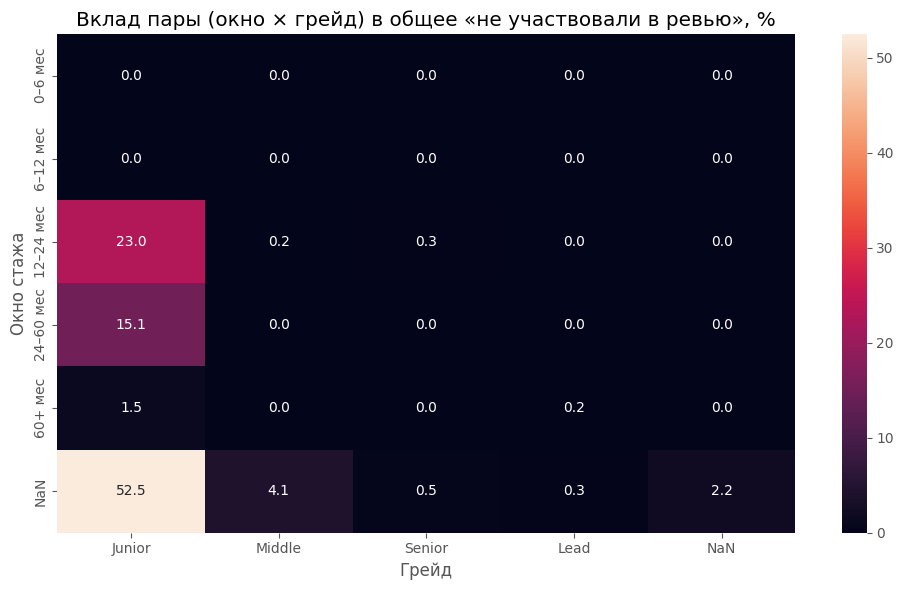

,
0,Сводная по всем оценкам ревью (count + % внутр...


,experience_window,seniority_grp,review_lbl,count,grp_total,pct_within_group
0,12–24 мес,Junior,Есть над чем поработать,5,166,3.01
1,12–24 мес,Junior,Не участвовал в ревью,134,166,80.72
2,12–24 мес,Junior,Огонь,3,166,1.81
3,12–24 мес,Junior,Хорошо,24,166,14.46
4,12–24 мес,Lead,Есть над чем поработать,1,6,16.67
5,12–24 мес,Lead,Огонь,1,6,16.67
6,12–24 мес,Lead,Хорошо,4,6,66.67
7,12–24 мес,Middle,Есть над чем поработать,12,43,27.91
8,12–24 мес,Middle,Не участвовал в ревью,1,43,2.33
9,12–24 мес,Middle,Огонь,5,43,11.63


,
0,"Только «Не участвовал в ревью» (count, % внутр..."


,experience_window,seniority_grp,count,pct_within_group,share_of_all_no_review_%
0,12–24 мес,Junior,134,80.72,22.98
1,12–24 мес,Middle,1,2.33,0.17
2,12–24 мес,Senior,2,25.00,0.34
3,24–60 мес,Junior,88,76.52,15.09
4,60+ мес,Junior,9,39.13,1.54
5,60+ мес,Lead,1,14.29,0.17
6,NaN,Junior,306,95.33,52.49
7,NaN,Lead,2,40.00,0.34
8,NaN,Middle,24,64.86,4.12
9,NaN,NaN,13,100.00,2.23


,
0,Матрица % внутри пары (heatmap выше)


seniority_grp,Junior,Middle,Senior,Lead,NaN
experience_window,,,,,
0–6 мес,NaN,NaN,NaN,NaN,NaN
6–12 мес,NaN,NaN,NaN,NaN,NaN
12–24 мес,80.72,2.33,25.0,NaN,NaN
24–60 мес,76.52,NaN,NaN,NaN,NaN
60+ мес,39.13,NaN,NaN,14.29,NaN
NaN,95.33,64.86,37.5,40.00,100.0


,
0,Матрица вклада в общее «не участвовали» (heatm...


seniority_grp,Junior,Middle,Senior,Lead,NaN
experience_window,,,,,
0–6 мес,NaN,NaN,NaN,NaN,NaN
6–12 мес,NaN,NaN,NaN,NaN,NaN
12–24 мес,22.98,0.17,0.34,NaN,NaN
24–60 мес,15.09,NaN,NaN,NaN,NaN
60+ мес,1.54,NaN,NaN,0.17,NaN
NaN,52.49,4.12,0.51,0.34,2.23


Всего «не участвовали в ревью»: 583 чел. (71.01% от выборки).


In [20]:
# === B) Охват ревью по стажу и грейдам — УСТОЙЧИВЫЙ КОД С ДИАГНОСТИКОЙ ===
# Цель: кто именно «проваливается» в 71% без ревью?
# Метрика: Оценка_ревью_RLS × окна стажа (0–6, 6–12, 12–24, 24–60, 60+) × грейд

# 0) Диагностика входных колонок
req_cols = ["experience_group_detail", "seniority_RLS", "Оценка_ревью_RLS"]
missing_cols = [c for c in req_cols if c not in df_clean.columns]
assert not missing_cols, f"Нет колонок: {missing_cols}"

# 1) Укрупняем детализированный стаж в окна (без импорта, безопасно для category/NaN)
win_map = {
    # 0–6 мес
    "менее 1 нед": "0–6 мес", "1 нед - 1 мес": "0–6 мес", "1 мес - 2 мес": "0–6 мес",
    "2 мес - 3 мес": "0–6 мес", "3 мес - 4 мес": "0–6 мес", "4 мес - 5 мес": "0–6 мес",
    "5 мес - 6 мес": "0–6 мес", "менее 6 мес": "0–6 мес", "0-6 мес": "0–6 мес", "до 6 мес": "0–6 мес",
    # 6–12 мес
    "6 мес - 9 мес": "6–12 мес", "9 мес - 12 мес": "6–12 мес", "6 - 12 мес": "6–12 мес",
    # 12–24 мес
    "1 - 2 года": "12–24 мес",
    # 24–60 мес
    "2 - 3 года": "24–60 мес", "3 - 4 года": "24–60 мес", "4 - 5 лет": "24–60 мес", "2 - 5 лет": "24–60 мес",
    # 60+ мес
    "5 лет и более": "60+ мес", "5+ лет": "60+ мес",
}
def to_window(val):
    if pd.isna(val):
        return "NaN"
    return win_map.get(str(val).strip(), "NaN")

dfw = df_clean.copy()
dfw["experience_window"] = dfw["experience_group_detail"].map(to_window)

# 2) Явно маркируем пропуски текстовой меткой «NaN» для стабильных группировок
def label_nan(series, label="NaN"):
    if str(series.dtype) == "category":
        series = series.cat.add_categories([label])
    return series.fillna(label).astype(str)

dfw["seniority_grp"] = label_nan(dfw["seniority_RLS"])
dfw["review_lbl"]    = label_nan(dfw["Оценка_ревью_RLS"])

# 3) Базовая сводная: count по (окно стажа × грейд × оценка ревью)
grp_cols = ["experience_window", "seniority_grp", "review_lbl"]
base_tbl = (
    dfw.groupby(grp_cols, dropna=False)
       .size()
       .reset_index(name="count")
)

# 4) Считаем % внутри каждой пары (окно × грейд) ЧЕРЕЗ MERGE (устраняем ошибку reindex/assign)
grp_total = (
    base_tbl.groupby(["experience_window", "seniority_grp"], as_index=False)["count"]
            .sum()
            .rename(columns={"count": "grp_total"})
)
base_tbl = base_tbl.merge(grp_total, on=["experience_window", "seniority_grp"], how="left")
base_tbl["pct_within_group"] = (base_tbl["count"] / base_tbl["grp_total"] * 100).round(2)

# 5) Срез: «Не участвовал в ревью» + вклад в общее «без ревью»
no_review_lbl = "Не участвовал в ревью"
no_review_tbl = base_tbl.loc[base_tbl["review_lbl"] == no_review_lbl, [
    "experience_window", "seniority_grp", "count", "pct_within_group"
]].copy()

total_no_review = int(no_review_tbl["count"].sum())
no_review_tbl["share_of_all_no_review_%"] = (
    (no_review_tbl["count"] / max(total_no_review, 1) * 100).round(2)
)

# 6) Матрицы:
win_order   = ["0–6 мес","6–12 мес","12–24 мес","24–60 мес","60+ мес","NaN"]
grade_order = ["Intern","Junior","Middle","Senior","Lead","Principal","Head","NaN"]

mat_within = (
    no_review_tbl
    .pivot_table(index="experience_window", columns="seniority_grp",
                 values="pct_within_group", aggfunc="first")
    .reindex(index=win_order, columns=[g for g in grade_order if g in no_review_tbl["seniority_grp"].unique()])
)

mat_share_all = (
    no_review_tbl
    .pivot_table(index="experience_window", columns="seniority_grp",
                 values="share_of_all_no_review_%", aggfunc="first")
    .reindex(index=win_order, columns=[g for g in grade_order if g in no_review_tbl["seniority_grp"].unique()])
)

# 7) Визуализация (2 теплокарты)
plt.figure(figsize=(10, 6))
sns.heatmap(mat_within.fillna(0), annot=True, fmt=".1f")
plt.title('Доля «не участвовали в ревью» внутри пары (окно стажа × грейд), %')
plt.xlabel('Грейд')
plt.ylabel('Окно стажа')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(mat_share_all.fillna(0), annot=True, fmt=".1f")
plt.title('Вклад пары (окно × грейд) в общее «не участвовали в ревью», %')
plt.xlabel('Грейд')
plt.ylabel('Окно стажа')
plt.tight_layout()
plt.show()

# 8) Итоговые таблицы для интерпретации
display(pd.DataFrame({"": ["Сводная по всем оценкам ревью (count + % внутри пары)"]}))
display(base_tbl.sort_values(["experience_window","seniority_grp","review_lbl"]).reset_index(drop=True))

display(pd.DataFrame({"": ['Только «Не участвовал в ревью» (count, % внутри пары, % вклада в общее)']}))
display(no_review_tbl.sort_values(["experience_window","seniority_grp"]).reset_index(drop=True))

display(pd.DataFrame({"": ['Матрица % внутри пары (heatmap выше)']}))
display(mat_within)

display(pd.DataFrame({"": ['Матрица вклада в общее «не участвовали» (heatmap выше)']}))
display(mat_share_all)

print(f"Всего «не участвовали в ревью»: {total_no_review} чел. ({round(total_no_review/len(dfw)*100,2)}% от выборки).")


## B) Охват ревью по стажу и грейдам — простые выводы и что делать

### Где теряем охват ревью
- Почти весь «не было ревью» — это **Junior**: около **90%** всех случаев без ревью.
- Основные окна стажа среди «без ревью» у Junior:
  - **0–6 месяцев** — **29.7%** всех без ревью (173 из 583).
  - **6–12 месяцев** — **22.8%**.
  - **12–24 месяцев** — **23.0%**.
  - **24–60 месяцев** — **15.1%**.  
  Итого первые **2 года** дают ~**75.5%** всех «без ревью».

### Как выглядит ситуация внутри пар «стаж × грейд»
- **Junior:** без ревью почти все в **0–6 мес (99%)**, очень много в **6–12 мес (91%)** и **12–24 мес (81%)**; даже на **24–60 мес — 77%** без ревью.
- **Middle:** провал только в **0–6 мес (90%)**, дальше ревью в основном проводится.
- **Senior/Lead:** охват заметно лучше после первого полугодия.

**Вывод:** критическая зона — **Junior в первые 24 месяца** (и частично 24–60 мес).

### Почему так может быть
- Ревью запускается слишком поздно или нерегулярно — люди успевают уйти **до** первого ревью.
- Большие потоки новичков в массовых стримах — **не хватает рук** на ревью.
- Сотрудники на **ГПХ/самозанятости** выпадают из стандартного цикла.

### Что делаем (пошагово)
1. **Фиксируем базовый график ревью для всех форматов договоров:**
   - **Через 1 месяц** — короткий чек-ин (как прошёл онбординг).
   - **Через 3 месяца** — мини-ревью с обратной связью и планом развития.
   - **Через 6 месяцев** — промежуточное ревью (при необходимости — обучение/наставник).
   - **Через 12 месяцев** — полное ревью, дальше — ежегодно.
2. **Целевой охват по Junior 0–24 мес:** не ниже **90%** в каждом окне (0–6; 6–12; 12–24).
3. **Подключаем ГПХ/самозанятых** к упрощённому мини-ревью, чтобы они **не выпадали**.
4. **Назначаем ответственных:** у каждого новичка есть ревьюер (руководитель/наставник); HRBP контролирует сроки.
5. **Для массовых команд** (например, Поддержка) — проводим ревью «потоками»: фиксированные «ревью-дни», единые шаблоны и чек-листы.
6. **Автоматические напоминания:** еженедельно список тех, у кого ревью через 30/7 дней; просрочки — в эскалацию.

### Чего ожидаем
- **Охват ревью Junior 0–24 мес** вырастет до **≥90%**.
- **Ранний отток** (6–24 мес) снизится на **15–20%** благодаря ранней обратной связи.
- Доля оценок **«Хорошо/Огонь»** у Junior 6–24 мес вырастет примерно на **10 п.п.**
- Доля причины **«Низкая эффективность»** в увольнениях начнёт снижаться на **3–5 п.п. в квартал**.


## C) Стрим «Analyst» — портрет уходящих и сравнение с остальными
**Зачем:** понять, почему уходит 60 аналитиков, и чем их паттерн увольнений отличается от остальных сотрудников.

**На какой вопрос отвечает:**
- Как распределяются аналитики по стажу/окнам стажа и грейдам среди ушедших?
- Кто чаще инициирует увольнение у аналитиков и какие группы причин/конкретные причины доминируют?
- Чем профиль причин у Analyst отличается от «не Analyst» (в процентах и разнице в п.п.) и какие отличия статистически заметны?
- Какие подгруппы Analyst (по стажу/грейду) тянут основной вклад в отток и требуют приоритета в удержании?


In [21]:
# === C) Стрим «Analyst» — портрет уходящих и сравнение с остальными ===
# Вопрос: почему уходит 60 аналитиков?
# Что считаем: распределения по стажу, окнам стажа, грейду, инициатору, группам и конкретным причинам;
#             сравнение с «не Analyst» (в процентах и п.п. делте)

SEG_COL = "Стрим"
SEG_VAL = "Analyst"

assert SEG_COL in df_clean.columns, f"Нет колонки {SEG_COL}"

# 0) Готовим окно стажа (если ещё не создано) — безопасно, без повторных импортов
if "experience_window" not in df_clean.columns:
    win_map = {
        # 0–6 мес
        "менее 1 нед": "0–6 мес", "1 нед - 1 мес": "0–6 мес", "1 мес - 2 мес": "0–6 мес",
        "2 мес - 3 мес": "0–6 мес", "3 мес - 4 мес": "0–6 мес", "4 мес - 5 мес": "0–6 мес",
        "5 мес - 6 мес": "0–6 мес", "менее 6 мес": "0–6 мес", "0-6 мес": "0–6 мес", "до 6 мес": "0–6 мес",
        # 6–12 мес
        "6 мес - 9 мес": "6–12 мес", "9 мес - 12 мес": "6–12 мес", "6 - 12 мес": "6–12 мес",
        # 12–24 мес
        "1 - 2 года": "12–24 мес",
        # 24–60 мес
        "2 - 3 года": "24–60 мес", "3 - 4 года": "24–60 мес", "4 - 5 лет": "24–60 мес", "2 - 5 лет": "24–60 мес",
        # 60+ мес
        "5 лет и более": "60+ мес", "5+ лет": "60+ мес",
    }
    def _to_win(x):
        if pd.isna(x): return "NaN"
        return win_map.get(str(x).strip(), "NaN")
    df_clean["experience_window"] = df_clean["experience_group_detail"].map(_to_win)

# 1) Маски сегмента и контроля
m_seg  = (df_clean[SEG_COL] == SEG_VAL)
m_rest = ~m_seg

n_seg  = int(m_seg.sum())
n_rest = int(m_rest.sum())
print(f"Стрим '{SEG_VAL}': {n_seg} записей; контроль (остальные): {n_rest} записей.")

# 2) Утилита сравнения распределений (Analyst vs остальные)
def compare_segment(df, mask, col, top_n=None, keep_order=True):
    assert col in df.columns, f"Нет колонки {col}"
    a = df.loc[mask, col]
    b = df.loc[~mask, col]

    # Учитываем категориальный порядок, если есть
    categories = None
    if str(df[col].dtype) == "category" and keep_order:
        categories = list(df[col].cat.categories)

    seg_counts  = a.value_counts(dropna=False)
    rest_counts = b.value_counts(dropna=False)

    # Универсальный индекс
    idx = list(set(seg_counts.index.tolist()) | set(rest_counts.index.tolist()))
    # Сортировка: если есть категориальный порядок — по нему, иначе по убыванию seg_counts
    if categories:
        idx = [c for c in categories if c in idx] + [c for c in idx if c not in categories]
    else:
        idx = pd.Index(idx)
        idx = seg_counts.reindex(idx).fillna(0).astype(int).sort_values(ascending=False).index.tolist()

    seg_counts  = seg_counts.reindex(idx).fillna(0).astype(int)
    rest_counts = rest_counts.reindex(idx).fillna(0).astype(int)

    seg_pct  = (seg_counts / max(len(a),1) * 100).round(2)
    rest_pct = (rest_counts / max(len(b),1) * 100).round(2)

    out = pd.DataFrame({
        "category": idx,
        "Analyst_count": seg_counts.values,
        "Analyst_pct": seg_pct.values,
        "Others_count": rest_counts.values,
        "Others_pct": rest_pct.values,
    })
    out["Delta_pp(Analyst - Others)"] = (out["Analyst_pct"] - out["Others_pct"]).round(2)

    # Сортируем по Analyst_count, при равенстве — по Delta_pp
    out = out.sort_values(["Analyst_count","Delta_pp(Analyst - Others)"], ascending=[False, False]).reset_index(drop=True)

    if top_n is not None:
        return out.head(top_n)
    return out

# 3) Считаем сравнения по нужным измерениям
tables = {}

for col in [
    "experience_group",         # общий стаж
    "experience_window",        # окна стажа
    "seniority_RLS",            # грейд
    "Инициатор увольнения_RLS", # инициатор
    "Группа причин увольнений_RLS",  # укрупнённые причины
    "Причина увольнения_RLS"         # конкретные причины
]:
    if col in df_clean.columns:
        tables[col] = compare_segment(df_clean, m_seg, col)

# 4) Доп. агрегат: сводный профиль Analyst коротко (по ключевым полям)
profile_cols = ["experience_group","experience_window","seniority_RLS",
                "Инициатор увольнения_RLS","Группа причин увольнений_RLS"]
profile = {}
for col in profile_cols:
    if col in df_clean.columns:
        vc = df_clean.loc[m_seg, col].value_counts(dropna=False)
        profile[col] = (vc.to_frame("count")
                          .assign(pct=lambda t: (t["count"]/max(n_seg,1)*100).round(2))
                          .reset_index().rename(columns={"index": col})
                       )

# 5) Выводим таблицы сравнения
display(pd.DataFrame({"": [f"Сравнение распределений для '{SEG_VAL}' vs остальные (count, %, Δп.п.)"]}))

for name, tbl in tables.items():
    display(pd.DataFrame({"": [f"► {name} — Analyst vs Others"]}))
    display(tbl)

# 6) Выводим краткий профиль Analyst по ключевым полям (только внутри сегмента)
display(pd.DataFrame({"": [f"Профиль внутри '{SEG_VAL}' (только сегмент, count и %)"]}))
for name, tbl in profile.items():
    display(pd.DataFrame({"": [f"• {name}"]}))
    display(tbl)

# 7) Подсветка Топ-10 конкретных причин увольнений у Analyst по Δп.п. к остальным
if "Причина увольнения_RLS" in tables:
    top_delta = (tables["Причина увольнения_RLS"]
                 .sort_values("Delta_pp(Analyst - Others)", ascending=False)
                 .head(10)
                 .reset_index(drop=True))
    display(pd.DataFrame({"": ["Топ-10 причин (Analyst) с наибольшей Δп.п. к остальным"]}))
    display(top_delta)

print("\nГотово. Пришли таблицы выше — дальше сделаю интерпретацию и рекомендации по стриму Analyst.")


Стрим 'Analyst': 60 записей; контроль (остальные): 761 записей.


,
0,Сравнение распределений для 'Analyst' vs остал...


,
0,► experience_group — Analyst vs Others


,category,Analyst_count,Analyst_pct,Others_count,Others_pct,Delta_pp(Analyst - Others)
0,Стаж от 1 до 2 лет,26,43.33,197,25.89,17.44
1,Стаж до 1 года,18,30.00,366,48.09,-18.09
2,Стаж от 2 до 5 лет,13,21.67,157,20.63,1.04
3,Стаж от 5 лет и более,3,5.00,41,5.39,-0.39
4,Без опыта,0,0.00,0,0.00,0.00


,
0,► experience_window — Analyst vs Others


...

,
0,• Группа причин увольнений_RLS


,Группа причин увольнений_RLS,count,pct
0,Релокация,18,30.00
1,Низкая эффективность,10,16.67
2,Финансы,10,16.67
3,Личное,9,15.00
4,Работа,8,13.33
5,Команда,3,5.00
6,Оптимизация,1,1.67
7,Компания,1,1.67
8,Мошенничество,0,0.00
9,Не соответствует духу команды/компании,0,0.00


,
0,Топ-10 причин (Analyst) с наибольшей Δп.п. к о...


,category,Analyst_count,Analyst_pct,Others_count,Others_pct,Delta_pp(Analyst - Others)
0,Переезд в другую страну,18,30.00,86,11.30,18.70
1,Не устраивает доход,10,16.67,51,6.70,9.97
2,Не нравятся задачи,5,8.33,22,2.89,5.44
3,Недопонимание с руководителем/коллегами,3,5.00,4,0.53,4.47
4,Нет профессионального/карьерного роста,3,5.00,15,1.97,3.03
5,Низкая скорость/качество выполнения задач,8,13.33,80,10.51,2.82
6,Низкая мотивация/выгорание,2,3.33,8,1.05,2.28
7,Оптимизация,1,1.67,3,0.39,1.28
8,Не подходит культура компании/внутренние регла...,1,1.67,11,1.45,0.22
9,Тюрьма,0,0.00,1,0.13,-0.13



Готово. Пришли таблицы выше — дальше сделаю интерпретацию и рекомендации по стриму Analyst.


## СЕГМЕНТ «Analyst» — кто уходит и что с этим делать

### Что видно по данным
- **Когда уходят:** пик на **12–24 месяцах** — **43.3%** всех увольнений Analyst (+17.4 п.п. к остальным). Ранний отток **0–6 мес** ниже рынка (**8.3% vs 27.1%, −18.7 п.п.**).
- **Кто уходит:** профиль «взрослее», чем у других стримов — **Middle 48.3% (+34.3 п.п.)**, **Senior 10.0% (+7.4 п.п.)**, **Lead 5.0% (+2.6 п.п.)**; **Junior** заметно меньше (**36.7% vs 79.2%, −42.6 п.п.**).
- **Инициатор:** больше **релокаций** (**30.0% vs 11.3%, +18.7 п.п.**), а добровольных уходов меньше (**51.7% vs 68.6%, −16.9 п.п.**).
- **Группы причин:** чаще всего **Релокация (30.0%)**, **Финансы (16.7%)**, **Низкая эффективность (16.7%)**. «Личное» — заметно ниже, чем у остальных (−27.2 п.п.).
- **Конкретные причины (выше, чем у остальных):**
  - **Переезд в другую страну — 30.0% (+18.7 п.п.)**
  - **Не устраивает доход — 16.7% (+10.0 п.п.)**
  - **Не нравятся задачи — 8.3% (+5.4 п.п.)**
  - **Низкая скорость/качество — 13.3% (+2.8 п.п.)**
  - **Недопонимание с руководителем — 5.0% (+4.5 п.п.)**, **нет роста — 5.0% (+3.0 п.п.)**

**Коротко:** у Analyst проблема не в онбординге. Основной риск — «плато» на **12–24 мес** у **Middle/Senior**: компенсация, интерес задач/рост, отношения с руководителем. Плюс сильный вклад релокаций.

---

### Что это может означать
1) **Карьерное плато к 1–2 годам:** ожидали рост и более сложные задачи — не получили.
2) **Компенсации ниже ожиданий/рынка** для аналитических профилей.
3) **Релокация:** внешний фактор, но часть людей можно удержать при гибких форматах работы.
4) **Сложности в совместной работе:** неясные ожидания, слабая обратная связь.
5) **Пробелы в навыках у части сотрудников** (эффективность, скорость/качество).

---

### План действий на 3–6 месяцев (приоритет)
**A. Удержание Middle/Senior (зона 12–24 мес)**
- Ввести **два понятных карьерных трека**: экспертный и руководящий; описать шаги роста на 12 месяцев вперёд.
- Запустить **внутреннюю витрину проектов** и **ротацию раз в 3–6 месяцев** — чтобы было больше «интересных задач».
- Провести **пересмотр компенсаций по грейдам** (сравнить с рынком и соседними ролями) и точечно исправить отставания.

**B. Снижение уходов из-за релокации**
- Разрешить **удалённую работу из другой страны** там, где это возможно.
- Использовать **оформление через зарубежного партнёра-работодателя** для ключевых специалистов (юридическая схема трудоустройства за пределами РФ).
- Предлагать **внутренние релокации** (если у компании есть юрлица/хабы за рубежом).

**C. Рост эффективности без «карательщины»**
- Запустить **короткие обучающие треки на 6–12 недель** (SQL/ETL, эксперименты, работа со стейкхолдерами).
- Если есть проблемы с результатом — **план улучшения** с наставником и **контроль каждые 2–3 недели**.
- Внедрить **регулярные ревью работ** (code/analysis review) и понятные стандарты качества/сроков.

**D. Работа с руководителями**
- Обучение лидов: постановка задач, приоритизация, обратная связь.
- **Ежемесячные 1:1** и **квартальные разговоры о карьере**, особенно для Middle с 9-го по 18-й месяц.

---

### Как поймём, что стало лучше (цели на 2–3 квартала)
- Увольнения Analyst на **12–24 мес** — **минус ≥20%**.
- Доля «Релокация» у Analyst — **минус 8–10 п.п.** (за счёт удалёнки/оформления через партнёра/внутренних релокаций).
- Причина «Не устраивает доход» — **минус 5 п.п.** после корректировок.
- «Не нравятся задачи» — **вдвое ниже** (за счёт ротации и витрины проектов).
- «Низкая эффективность» — **минус 3–5 п.п.** (после обучающих треков).
- Оценка вовлечённости Analyst (eNPS/опросы) — **+10 п.п.**.

---

### Что проверить дополнительно
- **Сравнение зарплат Analyst по грейдам**: с рынком и с соседними ролями внутри компании.
- **Охват ревью у Analyst** и связь «есть ревью ↔ удержание на 12–24 мес».
- **Где чаще «недопонимание с руководителем»** — карта команд/менеджеров.
- **Структура нагрузки**: доля рутины vs проектной работы vs развития.


## D) HQ (209 чел.) и «УС — Уровень 5»
**Зачем:** понять, кто уходит из HQ и чем HQ отличается от Line/Support, а также в каких подразделениях «УС — Уровень 5» концентрируется отток.

**На какой вопрос отвечает:**
- Какие грейды и стажевые окна внутри HQ дают основной вклад в уходы?
- Что с охватом ревью у HQ по сравнению с Line/Support?
- Какие группы и конкретные причины увольнений у HQ выше/ниже, чем у остальных?
- В каких единицах «УС — Уровень 5» доля уходов максимальна и где расхождение HQ ↔ остальные самое заметное?


In [22]:
# === D) Блок HQ (209 чел.) + «УС - Уровень 5» ===
# Вопрос: какой профиль у Hq и как распределён «УС - Уровень 5»?
# Считаем: Hq vs Line vs Support по грейдам, стажу, ревью, причинам; отдельно детально «УС - Уровень 5».

# 0) Подготовка рабочих колонок и порядков
dfw = df_clean.copy()

# Явные текстовые метки NaN для устойчивых сводных
def label_nan(series, label="NaN"):
    if str(series.dtype) == "category":
        series = series.cat.add_categories([label])
    return series.fillna(label).astype(str)

dfw["Покраска"] = label_nan(dfw["Покраска"])
dfw["seniority_RLS"] = label_nan(dfw["seniority_RLS"])
dfw["experience_group"] = label_nan(dfw["experience_group"])
dfw["experience_group_detail"] = label_nan(dfw["experience_group_detail"])
dfw["Оценка_ревью_RLS"] = label_nan(dfw["Оценка_ревью_RLS"])
dfw["Инициатор увольнения_RLS"] = label_nan(dfw["Инициатор увольнения_RLS"])
dfw["Группа причин увольнений_RLS"] = label_nan(dfw["Группа причин увольнений_RLS"])
dfw["Причина увольнения_RLS"] = label_nan(dfw["Причина увольнения_RLS"])

# Окна стажа — возьмём из предыдущего шага, при отсутствии — создадим
if "experience_window" not in dfw.columns:
    win_map = {
        # 0–6 мес
        "менее 1 нед": "0–6 мес","1 нед - 1 мес":"0–6 мес","1 мес - 2 мес":"0–6 мес",
        "2 мес - 3 мес":"0–6 мес","3 мес - 4 мес":"0–6 мес","4 мес - 5 мес":"0–6 мес",
        "5 мес - 6 мес":"0–6 мес","менее 6 мес":"0–6 мес","0-6 мес":"0–6 мес","до 6 мес":"0–6 мес",
        # 6–12 мес
        "6 мес - 9 мес":"6–12 мес","9 мес - 12 мес":"6–12 мес","6 - 12 мес":"6–12 мес",
        # 12–24 мес
        "1 - 2 года":"12–24 мес",
        # 24–60 мес
        "2 - 3 года":"24–60 мес","3 - 4 года":"24–60 мес","4 - 5 лет":"24–60 мес","2 - 5 лет":"24–60 мес",
        # 60+ мес
        "5 лет и более":"60+ мес","5+ лет":"60+ мес",
    }
    def _to_win(x):
        return win_map.get(str(x).strip(), "NaN")
    dfw["experience_window"] = dfw["experience_group_detail"].map(_to_win)
else:
    dfw["experience_window"] = label_nan(dfw["experience_window"])

# Порядок групп «Покраска»
group_col = "Покраска"
group_order = [g for g in ["Hq","Line","Support","NaN"] if g in dfw[group_col].unique()]

# 1) Универсальная функция: сводка Hq/Line/Support по измерению (count + % внутри группы)
def summarize_by_group(df, dimension, top_n=None):
    assert dimension in df.columns, f"Нет колонки: {dimension}"
    ct_count = pd.crosstab(df[dimension], df[group_col], dropna=False)
    # привести столбцы к нужному порядку
    present_cols = [c for c in group_order if c in ct_count.columns]
    ct_count = ct_count.reindex(columns=present_cols)
    # % внутри каждой группы (по столбцам)
    ct_colpct = (ct_count.div(ct_count.sum(axis=0).replace(0, pd.NA), axis=1) * 100).round(2)
    # Добавим итоги «All»
    ct_count["All_count"] = ct_count.sum(axis=1).astype(int)
    ct_colpct["All_pct"] = (ct_count["All_count"] / max(len(df),1) * 100).round(2)
    # При необходимости — усечём по топу
    if top_n is not None:
        top_idx = ct_count.sort_values("All_count", ascending=False).head(top_n).index
        ct_count = ct_count.loc[top_idx]
        ct_colpct = ct_colpct.loc[top_idx]
    return ct_count, ct_colpct

# 2) Функция «Hq vs Others»: дельта (п.п.) долей Hq к (Line+Support)
def hq_vs_others_delta(df, dimension, top_k=20):
    assert dimension in df.columns, f"Нет колонки: {dimension}"
    # распределение в процентах внутри групп
    ct = pd.crosstab(df[dimension], df[group_col], dropna=False)
    cols = ct.columns.tolist()
    # гарантия наличия столбцов
    for need in ["Hq","Line","Support"]:
        if need not in cols:
            ct[need] = 0
    # проценты по столбцам
    pct = (ct.div(ct.sum(axis=0).replace(0, pd.NA), axis=1) * 100).round(2)
    pct["Others"] = ((ct["Line"] + ct["Support"]) / (ct["Line"] + ct["Support"]).sum() * 100).round(2)
    out = pct[["Hq","Others"]].copy()
    out["Delta_pp(Hq - Others)"] = (out["Hq"] - out["Others"]).round(2)
    out = out.sort_values("Delta_pp(Hq - Others)", ascending=False)
    # Топ положительных и топ отрицательных (симметрично)
    pos = out.head(top_k)
    neg = out.tail(top_k)
    return pos, neg, pct

# 3) Считаем требуемые срезы: грейды, стаж, окна стажа, ревью, инициатор, группы и причины
dimensions = [
    ("seniority_RLS", "Грейд"),
    ("experience_group", "Стаж (общие группы)"),
    ("experience_window", "Стаж (окна)"),
    ("Оценка_ревью_RLS", "Оценка ревью"),
    ("Инициатор увольнения_RLS", "Инициатор увольнения"),
    ("Группа причин увольнений_RLS", "Группа причин увольнений"),
    ("Причина увольнения_RLS", "Причина увольнения (детально)"),
]

display(pd.DataFrame({"": [f"Размер групп «Покраска»: {dfw[group_col].value_counts(dropna=False).to_dict()}"]}))

for col, title in dimensions:
    if col not in dfw.columns:
        continue
    display(pd.DataFrame({"": [f"► {title}: распределение Hq / Line / Support — ABS counts"]}))
    ct_count, ct_colpct = summarize_by_group(dfw, col)  # все строки
    display(ct_count)
    display(pd.DataFrame({"": [f"► {title}: распределение Hq / Line / Support — % внутри группы"]}))
    display(ct_colpct)

    display(pd.DataFrame({"": [f"► {title}: Δ п.п. (Hq vs Others) — Топ положительных и отрицательных"]}))
    top_pos, top_neg, full_pct = hq_vs_others_delta(dfw, col, top_k=10)
    display(pd.DataFrame({"": ["Топ +Δ п.п. (Hq выше, чем Others)"]}))
    display(top_pos.reset_index().rename(columns={"index": col}))
    display(pd.DataFrame({"": ["Топ −Δ п.п. (Hq ниже, чем Others)"]}))
    display(top_neg.reset_index().rename(columns={"index": col}))

# 4) Детально «УС - Уровень 5»
lvl5_col = "УС - Уровень 5"
if lvl5_col in dfw.columns:
    display(pd.DataFrame({"": [f"► {lvl5_col}: распределение внутри Hq / Line / Support — ABS и %"]}))
    l5_counts, l5_pct = summarize_by_group(dfw, lvl5_col)
    display(l5_counts)
    display(l5_pct)

    # Как «УС - Уровень 5» распределён именно в Hq (внутренний профиль Hq)
    mask_hq = dfw[group_col] == "Hq"
    l5_hq = (dfw.loc[mask_hq, lvl5_col]
             .value_counts(dropna=False)
             .to_frame("Hq_count")
             .assign(Hq_pct=lambda t: (t["Hq_count"] / max(mask_hq.sum(),1) * 100).round(2))
             .reset_index().rename(columns={"index": lvl5_col}))
    display(pd.DataFrame({"": [f"• {lvl5_col} — профиль Hq (только сегмент Hq)"]}))
    display(l5_hq)

    # Δ п.п. по «УС - Уровень 5» (Hq vs Others)
    top_pos_l5, top_neg_l5, full_pct_l5 = hq_vs_others_delta(dfw, lvl5_col, top_k=20)
    display(pd.DataFrame({"": [f"• {lvl5_col} — Δ п.п. (Hq vs Others)"]}))
    display(top_pos_l5.reset_index().rename(columns={"index": lvl5_col}))
    display(top_neg_l5.reset_index().rename(columns={"index": lvl5_col}))
else:
    print(f"Колонка «{lvl5_col}» не найдена. Проверьте точное имя в датасете.")

print("\nГотово. Пришли таблицы/сводки — подготовлю выводы и рекомендации по блоку Hq и «УС - Уровень 5».")


,
0,"Размер групп «Покраска»: {'Line': 555, 'Hq': 2..."


,
0,► Грейд: распределение Hq / Line / Support — A...


Покраска,Hq,Line,Support,NaN,All_count
seniority_RLS,,,,,
Junior,39,541,45,0,625
Lead,18,0,2,1,21
Middle,128,3,5,0,136
NaN,1,11,0,1,13
Senior,23,0,3,0,26


,
0,► Грейд: распределение Hq / Line / Support — %...


Покраска,Hq,Line,Support,NaN,All_pct
seniority_RLS,,,,,
Junior,18.66,97.48,81.82,0.0,76.13
Lead,8.61,0.00,3.64,50.0,2.56
Middle,61.24,0.54,9.09,0.0,16.57
NaN,0.48,1.98,0.00,50.0,1.58
Senior,11.00,0.00,5.45,0.0,3.17


...

,УС - Уровень 5,Hq_count,Hq_pct
0,Управление технологий нефинансовых сервисов,57,27.27
1,Департамент информационных технологий Страхования,22,10.53
2,Тинькофф Страхование,19,9.09
3,Направление развития партнеров,14,6.70
4,Направление дизайна клиентских сервисов,10,4.78
5,Отдел маркетинга нефинансовых сервисов + Страх...,8,3.83
6,"Платформы Data Growth, Risk Tech, Origination",8,3.83
7,Направление продуктовой аналитики,8,3.83
8,Отдел развития бизнеса,5,2.39
9,Управление хранилищ данных и отчетности,5,2.39


,
0,• УС - Уровень 5 — Δ п.п. (Hq vs Others)


Покраска,УС - Уровень 5,Hq,Others,Delta_pp(Hq - Others)
0,Управление технологий нефинансовых сервисов,27.27,0.0,27.27
1,Департамент информационных технологий Страхования,10.53,0.0,10.53
2,Направление развития партнеров,6.70,0.0,6.70
3,Направление дизайна клиентских сервисов,4.78,0.0,4.78
4,Отдел маркетинга нефинансовых сервисов + Страх...,3.83,0.0,3.83
5,"Платформы Data Growth, Risk Tech, Origination",3.83,0.0,3.83
6,Направление продуктовой аналитики,3.83,0.0,3.83
7,Отдел развития бизнеса,2.39,0.0,2.39
8,Управление хранилищ данных и отчетности,2.39,0.0,2.39
9,Направление экосистемной аналитики,2.39,0.0,2.39


Покраска,УС - Уровень 5,Hq,Others,Delta_pp(Hq - Others)
0,Отдел портфельного менеджмента и аналитики,0.96,0.00,0.96
1,Отдел развития тревел-продукта,0.96,0.00,0.96
2,Направление продуктовых коммуникаций,0.96,0.00,0.96
3,Отдел кросс-селл маркетинга,0.96,0.00,0.96
4,Управление аналитики и прогнозирования,1.44,0.49,0.95
5,Growth team расчетные продукты,0.48,0.00,0.48
6,Направление партнерского маркетинга,0.48,0.00,0.48
7,Направление платного привлечения,0.48,0.00,0.48
8,Отдел репутационного маркетинга,0.48,0.00,0.48
9,Отдел развития пользовательских интерфейсов,0.48,0.00,0.48



Готово. Пришли таблицы/сводки — подготовлю выводы и рекомендации по блоку Hq и «УС - Уровень 5».


## HQ (209 чел.) — кто уходит и что делать

### Что видно по данным
- **Профиль старше и стабильнее:** в HQ больше **Middle/Senior/Lead** (Middle 61%), меньше Junior (19%). Стаж смещён в **1–5 лет**.
- **Ревью поставлено лучше:** «Хорошо/Огонь» — **64%**, «Не участвовал» — **22%** (сильно ниже остальных).
- **Кто инициирует уход:** в HQ больше **релокаций (31%)** и **увольнений по инициативе работодателя (25%)**, меньше добровольных.
- **Главные причины:** **Релокация**, **Финансы**, **Низкая эффективность**. Реже встречаются «Личное» и «Работа».
- **Детализация причин (выше, чем у остальных):** переезд за границу (31%), не устраивает доход (18%), низкая скорость/качество (20%), не нравятся задачи, нет роста, недопонимание с руководителем.

### Где сосредоточены HQ (УС-уровень 5)
Крупные блоки: **Управление технологий нефинансовых сервисов (27%)**, **Департамент ИТ Страхования (11%)**, **Тинькофф Страхование (9%)**, далее — платформы Data/Risk/Origination, продуктовая и экосистемная аналитика, хранилища данных, дизайн и маркетинг. Это ядро **ИТ/аналитики/продукта/маркетинга**.

---

### Что делаем в ближайшие 3–6 месяцев
**1) География (снижаем «Релокацию»)**  
Remote по согласованию для подходящих ролей, оформление через зарубежного провайдера (EOR) для ключевых специалистов, внутренняя релокация при возможности.  
**Цель:** доля «Релокация» в HQ **–8–10 п.п.** за 2–3 кв.

**2) Деньги (снижаем «Финансы»)**  
Бенчмарк вилок по УС-5 (P50/P75 рынка), compa-ratio по грейдам, точечные корректировки в дефицитных направлениях.  
**Цель:** «Финансы» **–5 п.п.**.

**3) Эффективность (не только «увольнение по результатам»)**  
Короткие enablement-треки 6–12 недель (скорость/качество, приоритизация, работа со стейкхолдерами), регулярные ревью работ (code/analysis/design review), PIP как продолжение обучения с чек-поинтами каждые 2–3 недели.  
**Цель:** «Низкая эффективность» **–5 п.п.**.

**4) Содержание задач и рост**  
Витрина проектов и ротации каждые 3–6 мес, два карьерных трека (IC/Lead), персональные growth-планы после ревью.  
**Цели:** «Не нравятся задачи» — **в 2 раза ниже**, «Нет роста» **–2–3 п.п.**.

**5) Менеджмент**  
Тренинги лидов по постановке задач и обратной связи, ежемесячные 1:1 и квартальные калибровки, мониторинг кейсов «недопонимания с руководителем».  
**Цель:** «Недопонимание» **–1–2 п.п.**.

---

### Как контролируем (метрики)
- Сплит причин по инициатору (voluntary / employer-initiated) — хотим **больше voluntary** при снижении «релокации».
- Доли причин в HQ: **Релокация, Финансы, Низкая эффективность** — отслеживаем против целей.
- **Coverage ревью в HQ ≥ 90%**.
- **Compa-ratio** по ключевым УС-5 и доля сотрудников с актуальным **growth-планом**.
- **Time-to-rotation** (средний интервал проектной ротации).

---

### Куда прицелиться в первую очередь (УС-5)
**УТНС**, **Деп. ИТ Страхования**, **Тинькофф Страхование**, **платформы Data/Risk/Origination**, **продуктовая/экосистемная аналитика**, **ХД** — здесь сосредоточен наибольший вклад HQ-оттока → начинаем с компенсаций, remote/EOR и enablement именно тут.

> **Итог:** HQ — зрелый, технологичный контур с хорошими процессами ревью. Отток формируют **релокация, компенсация и эффективность/совпадение роли**. Комбинация **remote/EOR + зарплатный бенчмарк + enablement и проектная ротация** должна заметно снизить риски.


## E) Увольнения по инициативе работодателя (152 чел.)
**Зачем:** понять профиль сотрудников, с которыми компания расторгла договор, и чем они отличаются от остальных — чтобы улучшить отбор, адаптацию, управление результативностью и профилактику нарушений.

**На какой вопрос отвечает:**
- Какие грейды и стажевые группы чаще всего попадают под увольнение по инициативе работодателя?
- В каких стримах таких случаев больше, и каков вклад формата договора (штат, ГПХ и т. п.)?
- Как выглядели оценки ревью у этих сотрудников перед увольнением?
- Какие группы и конкретные причины доминируют в этом сегменте по сравнению с остальными?
- Какие подгруппы требуют первоочередных мер (обучение руководителей, усиление онбординга, контроль качества и дисциплины)?


In [23]:
# === E) Увольнения по инициативе работодателя (152 чел.) — профиль и сравнение ===
# Вопрос: кто это? (грейды, стаж, стримы, ревью, причины)
# Считаем: распределения внутри сегмента и дельты к остальным (в п.п.)

dfw = df_clean.copy()

# 0) Устойчивые текстовые метки NaN для группировок
def label_nan(series, label="NaN"):
    if str(series.dtype) == "category":
        series = series.cat.add_categories([label])
    return series.fillna(label).astype(str)

cols_need = [
    "seniority_RLS","experience_group","experience_group_detail","Стрим",
    "Оценка_ревью_RLS","Тип трудоустройства",
    "Инициатор увольнения_RLS","Группа причин увольнений_RLS","Причина увольнения_RLS"
]
for c in cols_need:
    if c in dfw.columns:
        dfw[c] = label_nan(dfw[c])

# 1) Окна стажа (если ещё не созданы)
if "experience_window" not in dfw.columns:
    win_map = {
        # 0–6 мес
        "менее 1 нед":"0–6 мес","1 нед - 1 мес":"0–6 мес","1 мес - 2 мес":"0–6 мес",
        "2 мес - 3 мес":"0–6 мес","3 мес - 4 мес":"0–6 мес","4 мес - 5 мес":"0–6 мес",
        "5 мес - 6 мес":"0–6 мес","менее 6 мес":"0–6 мес","0-6 мес":"0–6 мес","до 6 мес":"0–6 мес",
        # 6–12 мес
        "6 мес - 9 мес":"6–12 мес","9 мес - 12 мес":"6–12 мес","6 - 12 мес":"6–12 мес",
        # 12–24 мес
        "1 - 2 года":"12–24 мес",
        # 24–60 мес
        "2 - 3 года":"24–60 мес","3 - 4 года":"24–60 мес","4 - 5 лет":"24–60 мес","2 - 5 лет":"24–60 мес",
        # 60+ мес
        "5 лет и более":"60+ мес","5+ лет":"60+ мес",
    }
    dfw["experience_window"] = dfw["experience_group_detail"].map(lambda x: win_map.get(str(x).strip(), "NaN"))
else:
    dfw["experience_window"] = label_nan(dfw["experience_window"])

# 2) Маска сегмента «Инициатива работодателя»
SEG_COL = "Инициатор увольнения_RLS"
SEG_VAL = "Инициатива работодателя"
mask_emp = (dfw[SEG_COL] == SEG_VAL)

n_seg, n_rest = int(mask_emp.sum()), int((~mask_emp).sum())
display(pd.DataFrame({"": [f"Размеры: Инициатива работодателя = {n_seg}, Остальные = {n_rest}, Всего = {len(dfw)}"]}))

# 3) Утилита сравнения сегмента с остальными
def compare_segment(df, mask, col, keep_order=True):
    a = df.loc[mask, col]
    b = df.loc[~mask, col]

    # учтём возможный категориальный порядок
    categories = None
    if str(df[col].dtype) == "category" and keep_order:
        categories = list(df[col].cat.categories)

    seg_counts  = a.value_counts(dropna=False)
    rest_counts = b.value_counts(dropna=False)

    idx = list(set(seg_counts.index.tolist()) | set(rest_counts.index.tolist()))
    if categories:
        idx = [c for c in categories if c in idx] + [c for c in idx if c not in categories]
    else:
        # по убыванию сегмента
        idx = pd.Index(idx)
        idx = seg_counts.reindex(idx).fillna(0).astype(int).sort_values(ascending=False).index.tolist()

    seg_counts  = seg_counts.reindex(idx).fillna(0).astype(int)
    rest_counts = rest_counts.reindex(idx).fillna(0).astype(int)

    seg_pct  = (seg_counts / max(len(a),1) * 100).round(2)
    rest_pct = (rest_counts / max(len(b),1) * 100).round(2)

    out = pd.DataFrame({
        "category": idx,
        "EmpInit_count": seg_counts.values,
        "EmpInit_pct": seg_pct.values,
        "Others_count": rest_counts.values,
        "Others_pct": rest_pct.values,
    })
    out["Delta_pp(EmpInit - Others)"] = (out["EmpInit_pct"] - out["Others_pct"]).round(2)
    return out

# 4) Список измерений для разбора
dims = [
    ("seniority_RLS", "Грейд"),
    ("experience_group", "Стаж (общие группы)"),
    ("experience_window", "Стаж (окна)"),
    ("Стрим", "Стрим"),
    ("Оценка_ревью_RLS", "Оценка ревью"),
    ("Тип трудоустройства", "Тип трудоустройства"),
    ("Группа причин увольнений_RLS", "Группа причин увольнений"),
    ("Причина увольнения_RLS", "Причина увольнения (детально)"),
]

# 5) Таблицы сравнения EmpInit vs Others
display(pd.DataFrame({"": ["Сравнение распределений (Инициатива работодателя vs Остальные): count, %, Δ п.п."]}))
tables = {}
for col, title in dims:
    if col not in dfw.columns:
        continue
    tbl = compare_segment(dfw, mask_emp, col)
    tables[col] = tbl
    display(pd.DataFrame({"": [f"► {title}"]}))
    display(tbl)

# 6) Короткий профиль внутри сегмента EmpInit (только сегмент)
display(pd.DataFrame({"": ["Профиль внутри сегмента (только Инициатива работодателя): count и %"]}))
profile_cols = ["seniority_RLS","experience_group","experience_window","Стрим",
                "Оценка_ревью_RLS","Группа причин увольнений_RLS","Причина увольнения_RLS","Тип трудоустройства"]
for col in profile_cols:
    if col in dfw.columns:
        vc = dfw.loc[mask_emp, col].value_counts(dropna=False)
        prof = (vc.to_frame("count")
                  .assign(pct=lambda t: (t["count"]/max(n_seg,1)*100).round(2))
                  .reset_index().rename(columns={"index": col}))
        display(pd.DataFrame({"": [f"• {col}"]}))
        display(prof)

# 7) Подсветка ТОП-10 детальных причин с наибольшей Δ п.п. (EmpInit - Others)
if "Причина увольнения_RLS" in tables:
    top_delta = (tables["Причина увольнения_RLS"]
                 .sort_values("Delta_pp(EmpInit - Others)", ascending=False)
                 .head(10)
                 .reset_index(drop=True))
    display(pd.DataFrame({"": ["ТОП-10 причин (EmpInit) по Δ п.п. к остальным"]}))
    display(top_delta)

print("\nГотово. Пришли таблицы — подготовлю выводы и рекомендованные меры по сегменту «Инициатива работодателя».")


,
0,"Размеры: Инициатива работодателя = 152, Осталь..."


,
0,Сравнение распределений (Инициатива работодате...


,
0,► Грейд


,category,EmpInit_count,EmpInit_pct,Others_count,Others_pct,Delta_pp(EmpInit - Others)
0,Junior,104,68.42,521,77.88,-9.46
1,Middle,31,20.39,105,15.70,4.69
2,Senior,8,5.26,18,2.69,2.57
3,Lead,6,3.95,15,2.24,1.71
4,NaN,3,1.97,10,1.49,0.48


,
0,► Стаж (общие группы)


...

,
0,• Тип трудоустройства


,Тип трудоустройства,count,pct
0,Штатный сотрудник,111,73.03
1,ГПХ,35,23.03
2,Самозанятый,4,2.63
3,ИП,1,0.66
4,Сотрудник иностранной организации,1,0.66


,
0,ТОП-10 причин (EmpInit) по Δ п.п. к остальным


,category,EmpInit_count,EmpInit_pct,Others_count,Others_pct,Delta_pp(EmpInit - Others)
0,Низкая скорость/качество выполнения задач,88,57.89,0,0.00,57.89
1,Нарушение правил работы/дисциплины,19,12.50,0,0.00,12.50
2,Неактивность (глухарь),13,8.55,0,0.00,8.55
3,Низкая мотивация/выгорание,10,6.58,0,0.00,6.58
4,Не соответствует духу команды/компании,10,6.58,0,0.00,6.58
5,Мошенничество,8,5.26,0,0.00,5.26
6,Оптимизация,4,2.63,0,0.00,2.63
7,Тюрьма,0,0.00,1,0.15,-0.15
8,Смерть,0,0.00,3,0.45,-0.45
9,Недопонимание с руководителем/коллегами,0,0.00,7,1.05,-1.05



Готово. Пришли таблицы — подготовлю выводы и рекомендованные меры по сегменту «Инициатива работодателя».


## E. Увольнения по инициативе работодателя (152 чел.) — коротко и по делу

### Коротко
Это в основном **Junior с опытом до 2 лет** в операционных потоках. Главный драйвер — **низкая производительность** (скорость/качество, неактивность) и **дисциплинарные нарушения**. У многих **не было ревью**.

---

### Кто это (портрет)
- **Грейд:** Junior **68%**, Middle **20%** (выше нормы), Senior/Lead — по ~**5%** каждый.  
- **Стаж:** **0–12 мес — 50%**, **12–24 мес — 29%** → фокус на первые **2 года**.  
- **Стрим:** в первую очередь **Поддержка физ. лиц (51%)**, далее Analyst (7%), Страхование (6%), Управление проектами (5%), Back-end (3%).  
- **Ревью:** «Не участвовал» **68%**, «Есть над чем поработать» **16%** (много ранних «желтых флажков»).  
- **Договор:** **ГПХ 23%** и **самозанятые 3%** — заметно выше, чем у остальных.  
- **Причины:**  
  - **Группы:** «Низкая эффективность» **64%**, «Нарушение правил» **13%**, «Не соответствует духу команды» **7%**, «Мошенничество» **5%**.  
  - **Детально:** **низкая скорость/качество 58%**, **дисциплина 13%**, **неактивность 9%**, **низкая мотивация 7%**.

---

### Почему так (рабочие гипотезы)
1) **Слабый рэмп-ап** на массовых ролях → не успевают выйти на нужную скорость/качество.  
2) **Провалы в ревью:** у большинства его не было, где было — сигналы не переводятся в план улучшений.  
3) **Несовпадение ожиданий при найме:** реальная работа сложнее/интенсивнее, чем в описании.  
4) **ГПХ/самозанятые** выпадают из обучения/ревью/наставничества.  
5) **Менеджмент на линии:** разные практики контроля, обратной связи и дисциплины.

---

### План на 0–6 месяцев

**A. Быстрый разгон продуктивности (Junior 0–12 мес)**
- 90-дневная программа выхода на план: недельные KPI по скорости/качеству/ошибкам.
- Ежедневные мини-практикумы и симуляции, «теневой режим» первые 2–3 недели.
- Единые стандарты качества + еженедельные quality-review.

**B. «Помогать до наказаний» (вместо мгновенного увольнения)**
- Мини-ревью на **30/60/90 день** для всех типов договоров.
- **Программа улучшений на 4–6 недель**: наставник, недельные цели, контроль прогресса.
- Формальный план улучшений (**PIP**) как продолжение программы, а не замена.

**C. Дисциплина и неактивность**
- Прозрачная шкала нарушений и эскалаций (warning → обучение/PIP → решение).
- Авто-мониторинг пропусков/неактивности и короткие коуч-вмешательства.
- Базовые анти-фрод практики (рандом-аудит, двойные проверки) — там, где уместно.

**D. Нештатные форматы (ГПХ/самозанятые)**
- Подключить к общему циклу: онбординг, мини-ревью, наставник, тренажёры.
- Пилот **конверсии лучших в штат** через 3–6 месяцев по понятным критериям.
- SLA в договорах: обязательные метрики качества/скорости и обучение.

**E. Найм и ожидания**
- **Realistic Job Preview:** пробная смена/симулятор до оффера.
- Кейс-интервью на скорость и точность для массовых ролей.
- Калибровать «планку» найма в локациях/потоках с наибольшим вкладом в «низкую скорость/качество».

**F. Менеджерский контур**
- Обучить супервизоров: быстрая обратная связь, SMART-цели, ведение программ улучшений.
- Еженедельные **1:1** в первые 90 дней; контроль просроченных ревью/планов.

---

### Как поймём, что работает (цели)
- **Доля увольнений по инициативе работодателя:** **–30%** за 2–3 квартала.  
- **Покрытие ревью в сегменте:** **≥90%** (сейчас «не участвовал» **68%**).  
- **«Низкая скорость/качество»:** **–15–20 п.п.**.  
- **Неактивность:** **–50%**.  
- **Доля ГПХ/самозанятых в увольнениях работодателя:** **–5–7 п.п.**.  
- **Конверсия «Есть над чем» → «Хорошо»** на 60–90 дне: **+10–15 п.п.**.

---

### Быстрые шаги (2–4 недели)
1) Дэшборд раннего риска (скорость, качество, неактивность, пропущенные ревью).  
2) Шаблоны программ улучшений и PIP + обучение линейных руководителей.  
3) Единая матрица ошибок и еженедельные quality-сессии.  
4) Подключить **ГПХ/самозанятых** к онбордингу/ревью; пилот конверсии в штат.  
5) Добавить **симулятор продуктивности** в процесс найма + честное описание работы.

> **Итог:** это «ранний» сегмент (Junior 0–24 мес) в массе, где не хватает рэмп-апа, ревью и менеджерских практик. Ставим систему: **быстрый разгон, помощь до санкций, дисциплина, включение ГПХ в общий цикл и калибровка найма** — и режем работодательские увольнения без потери качества сервиса.


## F) «Личное» и «Работа» (плюс контроль «Релокация»)
**Зачем:** понять, где и почему концентрируются увольнения по двум самым крупным группам причин — «Личное» и «Работа», а «Релокация» держать как контрольный фон (чтобы не смешивать бытовые/процессные причины с внешними факторами).

**На какой вопрос отвечает:**
- В каких стажевых окнах, грейдах, стримах и группах «Покраска» доля «Личное»/«Работа» повышена?
- Какие категории дают основной вклад в абсолютном числе уходов по этим группам?
- Какие конкретные причины (топ-5/топ-10) чаще всего встречаются в целом и в ключевых сегментах (Junior, HQ, Analyst)?
- Каков профиль по ревью и типу договора у тех, кто уходит по «Личное»/«Работа», — где логичнее запускать точечные меры (расписание и нагрузка, задачи и роль, карьерные шаги, условия, здоровье/баланс)?
- Насколько «Релокация» тянет цифры вверх в отдельных сегментах (и нужна ли отдельная политика/поддержка перемещения)?


In [24]:
# === F) «Личное» и «Работа» (и контрольный блок «Релокация») — кто даёт вклад и где выше доля ===
# Цель: детализировать группы причин увольнений «Личное» и «Работа» по ключевым срезам
#       + показать топ детальных причин внутри этих групп и по сегментам (Junior / Hq / Analyst).
# ВНИМАНИЕ: импортов не добавляем; используем df_clean и уже загруженные библиотеки.

# 0) Подготовка безопасных меток и окон стажа
dfw = df_clean.copy()

def label_nan(series, label="NaN"):
    if str(series.dtype) == "category":
        series = series.cat.add_categories([label])
    return series.fillna(label).astype(str)

need_cols = [
    "Группа причин увольнений_RLS","Причина увольнения_RLS",
    "seniority_RLS","experience_group_detail","experience_group","Покраска","Стрим",
    "Оценка_ревью_RLS","Тип трудоустройства"
]
for c in need_cols:
    if c in dfw.columns:
        dfw[c] = label_nan(dfw[c])

# Окна стажа (если не созданы)
if "experience_window" not in dfw.columns:
    win_map = {
        # 0–6 мес
        "менее 1 нед":"0–6 мес","1 нед - 1 мес":"0–6 мес","1 мес - 2 мес":"0–6 мес",
        "2 мес - 3 мес":"0–6 мес","3 мес - 4 мес":"0–6 мес","4 мес - 5 мес":"0–6 мес",
        "5 мес - 6 мес":"0–6 мес","менее 6 мес":"0–6 мес","0-6 мес":"0–6 мес","до 6 мес":"0–6 мес",
        # 6–12 мес
        "6 мес - 9 мес":"6–12 мес","9 мес - 12 мес":"6–12 мес","6 - 12 мес":"6–12 мес",
        # 12–24 мес
        "1 - 2 года":"12–24 мес",
        # 24–60 мес
        "2 - 3 года":"24–60 мес","3 - 4 года":"24–60 мес","4 - 5 лет":"24–60 мес","2 - 5 лет":"24–60 мес",
        # 60+ мес
        "5 лет и более":"60+ мес","5+ лет":"60+ мес",
        "NaN":"NaN",
    }
    dfw["experience_window"] = dfw["experience_group_detail"].map(lambda x: win_map.get(str(x).strip(), "NaN"))
else:
    dfw["experience_window"] = label_nan(dfw["experience_window"])

# 1) Универсальная функция сравнения группы причины по срезу:
#    - % reason внутри каждого значения измерения (сколько в этой категории уходит по этой группе)
#    - вклад категории в общее число увольнений по этой группе (contribution)
def reason_by_dimension(df, reason_group, dim, top_n=None):
    assert dim in df.columns, f"Нет колонки: {dim}"
    mask = (df["Группа причин увольнений_RLS"] == reason_group)
    total_reason = int(mask.sum())
    # счётчики в разрезе dim
    cnt_in_dim = df[dim].value_counts(dropna=False)
    cnt_reason_in_dim = df.loc[mask, dim].value_counts(dropna=False)

    idx = list(set(cnt_in_dim.index.tolist()) | set(cnt_reason_in_dim.index.tolist()))
    # фиксируем порядок: по числу увольнений по причине (reason) в убывании
    reason_counts = cnt_reason_in_dim.reindex(idx).fillna(0).astype(int)
    idx_sorted = reason_counts.sort_values(ascending=False).index.tolist()

    total_in_dim = cnt_in_dim.reindex(idx_sorted).fillna(0).astype(int)
    reason_counts = reason_counts.reindex(idx_sorted)

    pct_within_dim = (reason_counts / total_in_dim.replace(0, pd.NA) * 100).round(2)   # внутри категории
    contribution = (reason_counts / max(total_reason,1) * 100).round(2)               # вклад в общее reason

    out = pd.DataFrame({
        dim: idx_sorted,
        f"{reason_group}_count": reason_counts.values,
        f"{reason_group}_pct_within_dim": pct_within_dim.values,
        f"{reason_group}_share_of_reason_%": contribution.values,
        "category_total": total_in_dim.values
    })
    if top_n is not None:
        out = out.head(top_n)
    return out

# 2) Топ детальных причин внутри выбранной группы (общий и по сегментам)
def top_detailed_reasons(df, reason_group, segment_mask=None, segment_name="All", top_k=15):
    if segment_mask is None:
        segment_mask = pd.Series([True]*len(df), index=df.index)
    mask = (df["Группа причин увольнений_RLS"] == reason_group) & segment_mask
    vc = df.loc[mask, "Причина увольнения_RLS"].value_counts(dropna=False)
    tbl = (vc.to_frame("count")
             .assign(pct=lambda t: (t["count"]/max(int(mask.sum()),1)*100).round(2))
             .reset_index().rename(columns={"index":"Причина увольнения_RLS"})
             .head(top_k))
    meta = pd.DataFrame({"": [f"Топ детальных причин — {reason_group} — сегмент: {segment_name} (n={int(mask.sum())})"]})
    return meta, tbl

# 3) Сегменты для сравнения
seg_masks = {
    "All": pd.Series([True]*len(dfw), index=dfw.index),
    "Junior": (dfw["seniority_RLS"] == "Junior"),
    "Hq": (dfw["Покраска"] == "Hq"),
    "Analyst": (dfw["Стрим"] == "Analyst"),
}

# 4) Запускаем анализ для «Личное» и «Работа» (и контроль «Релокация»)
reasons_focus = ["Личное", "Работа", "Релокация"]  # третью оставим контрольной, т.к. она высока у Hq/Analyst

dims = [
    ("experience_window", "Стаж (окна)"),
    ("seniority_RLS", "Грейд"),
    ("Стрим", "Стрим"),
    ("Покраска", "Покраска"),
    ("Оценка_ревью_RLS", "Оценка ревью"),
    ("Тип трудоустройства", "Тип трудоустройства"),
]

for rg in reasons_focus:
    display(pd.DataFrame({"": [f"==== ГРУППА ПРИЧИН: {rg} ===="]}))
    # Сводки по срезам: где выше доля и кто даёт основной вклад
    for col, title in dims:
        tbl = reason_by_dimension(dfw, rg, col)
        display(pd.DataFrame({"": [f"► {title}: {rg} — (count, % внутри категории, вклад в общее {rg})"]}))
        display(tbl)

    # Топ-детализация причин (общий + ключевые сегменты)
    meta_all, tbl_all = top_detailed_reasons(dfw, rg, seg_masks["All"], "All", top_k=15)
    display(meta_all); display(tbl_all)

    for seg_name in ["Junior","Hq","Analyst"]:
        meta_seg, tbl_seg = top_detailed_reasons(dfw, rg, seg_masks[seg_name], seg_name, top_k=10)
        display(meta_seg); display(tbl_seg)

print("\nГотово. Пришлите сводные таблицы выше — сформирую выводы и адресные рекомендации по «Личное»/«Работа».")


,
0,==== ГРУППА ПРИЧИН: Личное ====


,
0,"► Стаж (окна): Личное — (count, % внутри катег..."


,experience_window,Личное_count,Личное_pct_within_dim,Личное_share_of_reason_%,category_total
0,NaN,179,46.61,54.24,384
1,12–24 мес,80,35.87,24.24,223
2,24–60 мес,56,32.94,16.97,170
3,60+ мес,15,34.09,4.55,44


,
0,"► Грейд: Личное — (count, % внутри категории, ..."


,seniority_RLS,Личное_count,Личное_pct_within_dim,Личное_share_of_reason_%,category_total
0,Junior,307,49.12,93.03,625
1,Middle,12,8.82,3.64,136
2,NaN,8,61.54,2.42,13
3,Senior,3,11.54,0.91,26
4,Lead,0,0.00,0.00,21


...

,
0,Топ детальных причин — Релокация — сегмент: Hq...


,Причина увольнения_RLS,count,pct
0,Переезд в другую страну,65,100.0


,
0,Топ детальных причин — Релокация — сегмент: An...


,Причина увольнения_RLS,count,pct
0,Переезд в другую страну,18,100.0



Готово. Пришлите сводные таблицы выше — сформирую выводы и адресные рекомендации по «Личное»/«Работа».


## F. «Личное» и «Работа» (+ контроль «Релокация») — коротко и по делу

### 1) «Личное» — кто уходит и почему
**Кто:** в основном **Junior** на раннем стаже (первые 12 месяцев), чаще в **Line/Поддержке**, чаще **без ревью**.  
**Почему:** «рассматривал как временную работу», дальше — пауза в работе, здоровье, учёба, семья.

**Что делаем (за 0–6 месяцев):**
- **Честный предварительный просмотр работы (RJP):** короткая «пробная смена»/симулятор до оффера.
- **Показать понятный путь роста для Junior:** шаги и сроки; первые точки контакта — **через 30/60/90 дней**.
- **Больше гибкости в графиках:** студенческие смены, «дружественные родителям» слоты.
- **Короткие перерывы без увольнения:** микро-саббатикалы 1–4 недели.
- **Обязательные мини-ревью** в первые 3 месяца (включая ГПХ/самозанятых).
- **Re-hire пул:** лёгкий возврат для «временных».

**Как проверим:**
- «Личное» у Junior/Line **−10 п.п.** за 2–3 квартала.
- Покрытие ревью в этой группе **≥90%**.
- Доля «временных», оставшихся **6+ месяцев**: **+15 п.п.**
- Запросы на гибкие графики, одобренные **≥80%** при сохранении SLA.

---

### 2) «Работа» — что болит и где
**Кто/где:** в Line — в основном **Junior**; в HQ/Analyst — больше про **содержание задач и рост**.  
**Почему:**  
- **Line:** высокий стресс/переработки, неудобные условия, «трение» в инструментах.  
- **HQ/Analyst:** «не нравятся задачи», «нет роста».

**Что делаем (за 0–6 месяцев):**
- **Управлять нагрузкой (Line):** прогноз потока, динамические смены, «буферные» слоты, правило «не две тяжёлые смены подряд».
- **Упростить работу:** горячие клавиши, авто-шаблоны, обновление слабого оборудования.
- **Поддержка людей:** быстрый доступ к супервайзеру, короткие сессии с психологом, контроль переработок.
- **Содержание и рост (HQ/Analyst):** внутренний **маркетплейс проектов**, «проба задач» на 10–20% ставки, два карьерных трека (эксперт/руководитель), growth-планы после ревью.
- **Дисциплина ревью:** мини-ревью на **30/60/90 день** с конкретным планом.

**Как проверим:**
- «Психологически тяжело/переработки» (Line) **−10–12 п.п.**
- «Не нравятся задачи» (HQ/Analyst) **−8–10 п.п.**, «нет роста» **−5 п.п.**
- Покрытие мини-ревью в группах риска **≥90%**.

---

### 3) Контроль «Релокация» — риск для цифровых ролей
**Кто:** чаще **Middle+** из **HQ/тех-стримов** (Back-end, QA, Analyst, Дизайн, Опер. аналитика).  
**Факт:** уходят **производительные** люди (по ревью часто «Хорошо»/«Огонь»).

**Что делаем:**
- **Удалёнка из-за рубежа**, где это возможно.
- **Оформление через зарубежных провайдеров (EOR)** или партнёров для ключевых специалистов.
- **Внутренняя релокация** (если есть хабы/юрлица) вместо ухода.
- **Адресные retention-пакеты** и ранний кадровый резерв на роли Middle.

**Как проверим:**
- Доля «Релокация» в HQ/тех-стримах **−8–10 п.п.**
- Не менее **40%** сотрудников с планом релокации остаются через remote/EOR.

---

### 4) Сквозные правила процесса
- **Единый цикл для всех (включая ГПХ/самозанятых):** ревью на 30/60/90 день → план действий → поддерживающая программа → при необходимости PIP.
- **Данные «на живую»:** дашборды по рискам раннего стажа, грейдам и потокам.
- **Пилоты и измеримость:** пробуем изменения графиков, перерывов и marketplace; фиксируем эффект на оттоке, SLA и NPS/CSAT.

**Итог:**  
- «Личное» — ранние Junior в Line, часто без ревью: даём честный вход, гибкость, поддержку и путь роста.  
- «Работа» — в Line про нагрузку/условия, в HQ/Analyst — про задачи и карьеру: разгружаем, улучшаем инструменты, открываем возможности.  
- «Релокация» — внешний риск для тех-ролей: спасаем через удалёнку, EOR и внутренние варианты.  
Ожидаемый эффект — снижение ключевых причин на **8–12 п.п.** при сохранении качества сервиса.


In [31]:
# === Топ-5 департаментов с худшей текучкой в первый год (≤12 мес) ===
# Цели:
# 1) Найти 5 департаментов с наибольшим числом увольнений при стаже ≤12 мес.
# 2) Понять, где у них больше всего уходов "до 3 месяцев".
# 3) Посмотреть причины этих уходов (группы и детали), в т.ч. инициатора.

t = df_clean.copy()

DEPT_COL   = "УС - Уровень 5"
DETAIL_COL = "experience_group_detail"
REASON_GRP = "Группа причин увольнений_RLS"
REASON_DET = "Причина увольнения_RLS"
INITIATOR  = "Инициатор увольнения_RLS"

# --- Безопасная подготовка строк для категориальных столбцов ---
def safe_label_str(s, label="NaN"):
    """Заполняем пропуски строковой меткой с учётом dtype=category."""
    if str(s.dtype) == "category":
        if label not in s.cat.categories:
            s = s.cat.add_categories([label])
        s = s.fillna(label)
        return s.astype(str)
    return s.fillna(label).astype(str)

def _norm(x):
    x = "" if x is None else str(x)
    x = x.strip().replace("—", "-").replace("–", "-")
    return " ".join(x.split())

# --- Проверки наличия колонок ---
for _c in [DEPT_COL, DETAIL_COL, REASON_GRP, REASON_DET, INITIATOR]:
    assert _c in t.columns, f"Нет обязательной колонки: '{_c}'"

# --- Нормализация / заполнение ---
t[DETAIL_COL] = t[DETAIL_COL].map(_norm)  # detail оставляем как свободный текст (могут быть разные окна)
t[DEPT_COL]   = safe_label_str(t[DEPT_COL], "NaN")
t[REASON_GRP] = safe_label_str(t[REASON_GRP], "NaN")
t[REASON_DET] = safe_label_str(t[REASON_DET], "NaN")
t[INITIATOR]  = safe_label_str(t[INITIATOR], "NaN")

# --- Маппинг детализированного стажа в интервалы первого года (4 окна) ---
# Делим укрупнёнки пополам: "0-6" -> 50/50 к "до 3" и "3–6"; "6-12" -> 50/50 к "6–9" и "9–12".
intervals = ["до 3 мес", "3–6 мес", "6–9 мес", "9–12 мес"]

def to_4bins(detail):
    s = detail.lower()
    # Точные интервалы
    if s in ["1 мес - 2 мес", "2 мес - 3 мес", "1 мес-2 мес", "2 мес-3 мес"]:
        return [("до 3 мес", 1.0)]
    if s in ["3 мес - 4 мес", "4 мес - 5 мес", "5 мес - 6 мес", "3 мес-4 мес", "4 мес-5 мес", "5 мес-6 мес"]:
        return [("3–6 мес", 1.0)]
    if s in ["6 мес - 9 мес", "6 мес-9 мес"]:
        return [("6–9 мес", 1.0)]
    if s in ["9 мес - 12 мес", "9 мес-12 мес"]:
        return [("9–12 мес", 1.0)]

    # Укрупнённые окна
    if s in ["менее 6 мес", "до 6 мес", "0-6 мес", "0 - 6 мес"]:
        return [("до 3 мес", 0.5), ("3–6 мес", 0.5)]
    if s in ["6 - 12 мес", "6-12 мес"]:
        return [("6–9 мес", 0.5), ("9–12 мес", 0.5)]

    # Совсем ранние окна (недели / <1 мес) — считаем как "до 3 мес"
    if "нед" in s or s in ["менее 1 нед", "1 нед - 1 мес", "1 нед-1 мес"]:
        return [("до 3 мес", 1.0)]

    # Всё, что старше 12 мес — не учитываем в витрине первого года
    if any(tok in s for tok in ["год", "лет", "года", "5+"]):
        return []

    # Нестандартные значения — пропускаем
    return []

# --- Делаем длинную таблицу dept × interval × weight + причины/инициатор ---
rows = []
for _, r in t.iterrows():
    allocs = to_4bins(r[DETAIL_COL])
    if not allocs:
        continue
    for itv, w in allocs:
        rows.append((
            r[DEPT_COL], itv, w,
            r[REASON_GRP], r[REASON_DET], r[INITIATOR]
        ))

long = pd.DataFrame(rows, columns=[DEPT_COL, "interval", "weight", REASON_GRP, REASON_DET, INITIATOR])

# --- Топ-5 департаментов по увольнениям в первый год (≤12 мес) ---
totals_12m = (
    long.groupby(DEPT_COL, as_index=False)["weight"].sum()
        .rename(columns={"weight": "count_<=12m"})
        .sort_values("count_<=12m", ascending=False)
)
top5_depts = totals_12m.head(5)[DEPT_COL].tolist()

display(pd.DataFrame({"": ["► Топ-5 департаментов по числу увольнений ≤12 мес"]}))
display(totals_12m.head(5).reset_index(drop=True))

# --- Распределение по окнам первого года для топ-5 (COUNT и доли внутри департамента) ---
top_long = long[long[DEPT_COL].isin(top5_depts)].copy()

pivot_counts = (
    top_long.groupby(["interval", DEPT_COL], as_index=False)["weight"].sum()
            .pivot(index="interval", columns=DEPT_COL, values="weight")
            .reindex(index=intervals, columns=top5_depts)
            .fillna(0.0)
)
dept_tot = pivot_counts.sum(axis=0).replace(0, pd.NA)
pivot_share = (pivot_counts.div(dept_tot, axis=1) * 100).round(2)

display(pd.DataFrame({"": ["► Распределение по интервалам (COUNT) — топ-5 департаментов"]}))
display(pivot_counts.round(2))

display(pd.DataFrame({"": ["► Доли по интервалам внутри департамента (%, от всех ≤12 мес в департаменте)"]}))
display(pivot_share)

# --- Где у топ-5 больше всего увольнений «до 3 мес» ---
leaders_upto3 = (
    pivot_counts.loc["до 3 мес"]
        .to_frame("count_upto3")
        .reset_index()
        .rename(columns={"index": DEPT_COL})
        .sort_values("count_upto3", ascending=False)
        .reset_index(drop=True)
)
leaders_upto3["pct_within_dept_<=12m"] = (
    leaders_upto3.apply(lambda r: (r["count_upto3"] / float(dept_tot[r[DEPT_COL]])) * 100 if pd.notna(dept_tot[r[DEPT_COL]]) and dept_tot[r[DEPT_COL]] != 0 else 0, axis=1)
).round(2)

display(pd.DataFrame({"": ["► Лидеры топ-5 по числу увольнений 'до 3 мес'"]}))
display(leaders_upto3)

# --- Причины увольнений «до 3 мес» среди топ-5 департаментов ---
mask_upto3 = (top_long["interval"] == "до 3 мес")

# Группы причин (агрегировано по всем топ-5)
reasons_group_agg = (
    top_long.loc[mask_upto3]
            .groupby(REASON_GRP, as_index=False)["weight"].sum()
            .rename(columns={"weight": "count"})
            .assign(pct=lambda d: (d["count"] / d["count"].sum() * 100).round(2))
            .sort_values(["count","pct"], ascending=[False, False])
)
display(pd.DataFrame({"": ["► Причины (группы) 'до 3 мес' — агрегировано по топ-5 департаментам"]}))
display(reasons_group_agg)

# Детальные причины (агрегировано по всем топ-5)
reasons_detail_agg = (
    top_long.loc[mask_upto3]
            .groupby(REASON_DET, as_index=False)["weight"].sum()
            .rename(columns={"weight": "count"})
            .assign(pct=lambda d: (d["count"] / d["count"].sum() * 100).round(2))
            .sort_values(["count","pct"], ascending=[False, False])
            .head(15)
)
display(pd.DataFrame({"": ["► ТОП-15 детальных причин 'до 3 мес' — агрегировано по топ-5 департаментам"]}))
display(reasons_detail_agg)

# Причины по каждому департаменту (группы)
per_dept_group = (
    top_long.loc[mask_upto3]
            .groupby([DEPT_COL, REASON_GRP], as_index=False)["weight"].sum()
)
dept_tot_upto3 = per_dept_group.groupby(DEPT_COL)["weight"].transform("sum").replace(0, pd.NA)
per_dept_group["pct_within_dept_upto3"] = (per_dept_group["weight"] / dept_tot_upto3 * 100).round(2)
per_dept_group = per_dept_group.sort_values([DEPT_COL, "weight"], ascending=[True, False])

display(pd.DataFrame({"": ["► Причины (группы) 'до 3 мес' — по каждому департаменту (count, % внутри департамента)"]}))
display(per_dept_group)

# ТОП-5 детальных причин 'до 3 мес' по каждому департаменту
per_dept_detail = (
    top_long.loc[mask_upto3]
            .groupby([DEPT_COL, REASON_DET], as_index=False)["weight"].sum()
)
dept_tot_upto3_det = per_dept_detail.groupby(DEPT_COL)["weight"].transform("sum").replace(0, pd.NA)
per_dept_detail["pct_within_dept_upto3"] = (per_dept_detail["weight"] / dept_tot_upto3_det * 100).round(2)
per_dept_detail = (
    per_dept_detail.sort_values([DEPT_COL, "weight"], ascending=[True, False])
                   .groupby(DEPT_COL)
                   .head(5)
                   .reset_index(drop=True)
)

display(pd.DataFrame({"": ["► ТОП-5 детальных причин 'до 3 мес' — по каждому департаменту"]}))
display(per_dept_detail)

# Инициатор (агрегировано по топ-5, «до 3 мес»)
initiator_agg = (
    top_long.loc[mask_upto3]
            .groupby(INITIATOR, as_index=False)["weight"].sum()
            .rename(columns={"weight": "count"})
            .assign(pct=lambda d: (d["count"] / d["count"].sum() * 100).round(2))
            .sort_values(["count","pct"], ascending=[False, False])
)
display(pd.DataFrame({"": ["► Инициатор увольнения 'до 3 мес' — агрегировано по топ-5 департаментам"]}))
display(initiator_agg)

print("\nГотово. В таблицах: топ-5 департаментов по ≤12 мес, их пики 'до 3 мес' и причины уходов (группы/детали).")


,
0,► Топ-5 департаментов по числу увольнений ≤12 мес


,УС - Уровень 5,count_<=12m
0,Поддержка клиентов инвестиций и мобайла,114.0
1,Поддержка банковских продуктов для физических лиц,97.0
2,Поддержка клиентов страхования,76.0
3,Тинькофф Страхование,32.0
4,Управление технологий нефинансовых сервисов,21.0


,
0,► Распределение по интервалам (COUNT) — топ-5 ...


УС - Уровень 5,Поддержка клиентов инвестиций и мобайла,Поддержка банковских продуктов для физических лиц,Поддержка клиентов страхования,Тинькофф Страхование,Управление технологий нефинансовых сервисов
interval,,,,,
до 3 мес,29.0,21.0,26.0,12.0,6.0
3–6 мес,39.0,30.0,21.0,5.0,4.0
6–9 мес,24.0,32.0,19.0,3.0,5.0
9–12 мес,22.0,14.0,10.0,12.0,6.0


,
0,"► Доли по интервалам внутри департамента (%, о..."


...

,
0,► ТОП-5 детальных причин 'до 3 мес' — по каждо...


,УС - Уровень 5,Причина увольнения_RLS,weight,pct_within_dept_upto3
0,Поддержка банковских продуктов для физических лиц,"Не нравятся условия работы (график, место рабо...",3.0,14.29
1,Поддержка банковских продуктов для физических лиц,Переезд в другую страну,3.0,14.29
2,Поддержка банковских продуктов для физических лиц,Психологически тяжело работать/сложно работать...,3.0,14.29
3,Поддержка банковских продуктов для физических лиц,Меняю профессию/ухожу в свой проект/рассматрив...,2.0,9.52
4,Поддержка банковских продуктов для физических лиц,Не могу совмещать c учебой,2.0,9.52
5,Поддержка клиентов инвестиций и мобайла,Меняю профессию/ухожу в свой проект/рассматрив...,12.0,41.38
6,Поддержка клиентов инвестиций и мобайла,Не могу/не хочу работать какое-то время,6.0,20.69
7,Поддержка клиентов инвестиций и мобайла,Не могу совмещать c учебой,3.0,10.34
8,Поддержка клиентов инвестиций и мобайла,Низкая скорость/качество выполнения задач,2.0,6.90
9,Поддержка клиентов инвестиций и мобайла,По состоянию здоровья (своего или близкого чел...,2.0,6.90


,
0,► Инициатор увольнения 'до 3 мес' — агрегирова...


,Инициатор увольнения_RLS,count,pct
1,Инициатива сотрудника,73.0,77.66
0,Инициатива работодателя,14.0,14.89
3,Релокация,5.0,5.32
2,Прочее,2.0,2.13



Готово. В таблицах: топ-5 департаментов по ≤12 мес, их пики 'до 3 мес' и причины уходов (группы/детали).
